In [2]:
import sqlite3
import pandas as pd
import numpy as np

def load_actual_data(db_path: str, table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            DateTime,
            SoC,
            P_PV,
            P_HOME,
            P_GRID,
            P_BAT,
            BUY_T,
            SELL_T
        FROM {table_name}
        ORDER BY DateTime
        """,
        conn
    )
    conn.close()

    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.set_index("DateTime").sort_index()
    return df

In [3]:
def load_spot_data(db_path: str, table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            DateTime,
            Value
        FROM {table_name}
        ORDER BY DateTime
        """,
        conn
    )
    conn.close()

    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.set_index("DateTime").sort_index()
    return df.rename(columns={"Value": "spot_price"})

In [4]:
import pandas as pd
import numpy as np

def resample_house_to_15min_gap_aware(
    df: pd.DataFrame,
    max_gap_minutes: int = 30,
    base_freq: str = "1min",
    clip_home_kw: float | None = None,
    clip_pv_kw: float | None = None,
    clip_bat_kw: float | None = None,
):
    out = df.copy().sort_index()

    # force numeric
    for col in ["P_HOME", "P_PV", "P_BAT", "SoC", "BUY_T", "SELL_T"]:
        if col in out.columns:
            out[col] = (
                out[col]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .pipe(pd.to_numeric, errors="coerce")
            )

    # convert W -> kW
    for col in ["P_HOME", "P_PV", "P_BAT"]:
        if col in out.columns:
            out[col] = out[col] / 1000.0

    signal_cols = [c for c in ["P_HOME", "P_PV", "P_BAT", "SoC"] if c in out.columns]

    # Raw -> regular 1-minute grid
    minute = out[signal_cols].resample(base_freq).mean()

    # Real observation present in each 1-minute bin
    present = out[signal_cols].resample(base_freq).count().max(axis=1) > 0

    # Interpolate on regular grid
    minute_interp = minute.interpolate(method="time", limit_area="inside")

    # Compute distance to nearest real observation on left/right
    idx_series = pd.Series(minute.index, index=minute.index)
    real_times = idx_series.where(present)

    last_real = real_times.ffill()
    next_real = real_times.bfill()

    dist_left_min = (idx_series - last_real).dt.total_seconds() / 60.0
    dist_right_min = (next_real - idx_series).dt.total_seconds() / 60.0

    # Keep interpolated values only if both sides are close enough
    valid_bridge = (dist_left_min <= max_gap_minutes) & (dist_right_min <= max_gap_minutes)

    minute_clean = minute_interp.copy()
    for col in signal_cols:
        minute_clean.loc[~valid_bridge, col] = np.nan

    # Optional clipping
    if clip_home_kw is not None and "P_HOME" in minute_clean.columns:
        minute_clean["P_HOME"] = minute_clean["P_HOME"].clip(lower=0, upper=clip_home_kw)

    if clip_pv_kw is not None and "P_PV" in minute_clean.columns:
        minute_clean["P_PV"] = minute_clean["P_PV"].clip(lower=0, upper=clip_pv_kw)

    if clip_bat_kw is not None and "P_BAT" in minute_clean.columns:
        minute_clean["P_BAT"] = minute_clean["P_BAT"].clip(lower=-clip_bat_kw, upper=clip_bat_kw)

    if "SoC" in minute_clean.columns:
        minute_clean["SoC"] = minute_clean["SoC"].clip(lower=0, upper=100)

    # Resample to 15-minute means
    resampled = minute_clean.resample("15min").mean()

    # Coverage and flags
    raw_points_1min = present.astype(int)
    resampled["raw_points"] = raw_points_1min.resample("15min").sum()

    valid_minutes_1min = valid_bridge.astype(int)
    resampled["valid_minutes"] = valid_minutes_1min.resample("15min").sum()

    resampled["low_coverage"] = resampled["raw_points"] < 2
    resampled["high_interpolation_share"] = resampled["valid_minutes"] < 10

    return resampled, minute_clean

In [5]:
import pandas as pd
import numpy as np

def resample_house_to_15min_safe(
    df: pd.DataFrame,
    max_interp_minutes: int = 30,
):
    out = df.copy().sort_index()

    # force numeric
    for col in ["P_HOME", "P_PV", "P_BAT", "SoC", "BUY_T", "SELL_T"]:
        if col in out.columns:
            out[col] = (
                out[col]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .pipe(pd.to_numeric, errors="coerce")
            )

    # convert W -> kW
    for col in ["P_HOME", "P_PV", "P_BAT"]:
        if col in out.columns:
            out[col] = out[col] / 1000.0

    signal_cols = [c for c in ["P_HOME", "P_PV", "P_BAT", "SoC"] if c in out.columns]

    # Step 1: aggregate raw second-level timestamps to 1-minute bins
    minute = out[signal_cols].resample("1min").mean()

    # Step 2: count how many raw points contributed to each 1-minute bin
    raw_points_1min = out[signal_cols].resample("1min").count()
    raw_points_1min["raw_points"] = raw_points_1min.max(axis=1)

    # Step 3: interpolate across up to max_interp_minutes consecutive 1-minute gaps
    minute[signal_cols] = minute[signal_cols].interpolate(
        method="time",
        limit=max_interp_minutes,
        limit_area="inside",
    )

    # Step 4: resample interpolated 1-minute data to 15-minute means
    resampled = minute.resample("15min").mean()

    # coverage from original raw data
    coverage_15 = raw_points_1min["raw_points"].resample("15min").sum()
    resampled["raw_points"] = coverage_15

    # simple flag
    resampled["low_coverage"] = resampled["raw_points"] < 2

    return resampled

In [6]:
def compute_no_battery_cost(df_actual: pd.DataFrame, df_spot: pd.DataFrame) -> pd.DataFrame:
    rs = resample_house_to_15min_safe(df_actual, max_interp_minutes=30)

    spot = df_spot.copy()
    spot["spot_price"] = (
        spot["spot_price"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    out = spot.join(rs[["P_HOME", "P_PV", "raw_points", "low_coverage"]], how="left")

    # drop bins where we still don't have usable data
    out = out.dropna(subset=["P_HOME", "P_PV", "spot_price"])

    dt = 0.25
    net_kwh = (out["P_HOME"] - out["P_PV"]) * dt

    out["nobatt_buy_kwh"] = net_kwh.clip(lower=0)
    out["nobatt_sell_kwh"] = (-net_kwh).clip(lower=0)
    out["nobatt_cost"] = (out["nobatt_buy_kwh"] - out["nobatt_sell_kwh"]) * out["spot_price"]

    return out

In [7]:
def daily_actual_cost(actual_cost_df: pd.DataFrame) -> pd.Series:
    return actual_cost_df["actual_cost"].resample("1D").sum()

In [8]:
def compute_actual_cost_from_cumulative(df_actual: pd.DataFrame, df_spot: pd.DataFrame) -> pd.DataFrame:
    df = df_actual.copy()
    spot = df_spot.copy()

    for col in ["BUY_T", "SELL_T"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

    spot["spot_price"] = (
        spot["spot_price"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    # raw timestamp deltas
    df["buy_kwh_delta"] = df["BUY_T"].diff()
    df["sell_kwh_delta"] = df["SELL_T"].diff()

    # remove bad counter jumps and resets
    df["buy_kwh_delta"] = df["buy_kwh_delta"].where((df["buy_kwh_delta"] >= 0) & (df["buy_kwh_delta"] < 100), np.nan)
    df["sell_kwh_delta"] = df["sell_kwh_delta"].where((df["sell_kwh_delta"] >= 0) & (df["sell_kwh_delta"] < 100), np.nan)

    # sum measured energy into 15-minute bins
    energy_15 = df.resample("15min").sum()[["buy_kwh_delta", "sell_kwh_delta"]]
    counts_15 = df.resample("15min").count()[["buy_kwh_delta", "sell_kwh_delta"]]

    out = spot.join(energy_15, how="left").join(
        counts_15.rename(columns={
            "buy_kwh_delta": "buy_count",
            "sell_kwh_delta": "sell_count"
        }),
        how="left"
    )

    out["buy_kwh_delta"] = out["buy_kwh_delta"].fillna(0)
    out["sell_kwh_delta"] = out["sell_kwh_delta"].fillna(0)

    # optional: mark intervals with no actual counter updates
    out["low_counter_coverage"] = (out["buy_count"].fillna(0) == 0) & (out["sell_count"].fillna(0) == 0)

    out["actual_cost"] = (out["buy_kwh_delta"] - out["sell_kwh_delta"]) * out["spot_price"]
    return out

In [9]:
import pandas as pd
import numpy as np

def compute_actual_cost_from_cumulative_safe(df_actual: pd.DataFrame, df_spot: pd.DataFrame) -> pd.DataFrame:
    df = df_actual.copy().sort_index()
    spot = df_spot.copy().sort_index()

    # numeric conversion
    for col in ["BUY_T", "SELL_T"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

    spot["spot_price"] = (
        spot["spot_price"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    # cumulative -> interval energy
    df["buy_kwh_delta"] = df["BUY_T"].diff()
    df["sell_kwh_delta"] = df["SELL_T"].diff()

    # remove resets / impossible jumps
    # tune upper bound if needed
    df["buy_kwh_delta"] = df["buy_kwh_delta"].where(
        (df["buy_kwh_delta"] >= 0) & (df["buy_kwh_delta"] <= 20),
        np.nan
    )
    df["sell_kwh_delta"] = df["sell_kwh_delta"].where(
        (df["sell_kwh_delta"] >= 0) & (df["sell_kwh_delta"] <= 20),
        np.nan
    )

    # Sum measured energy into 15-minute bins
    energy_15 = df.resample("15min").sum()[["buy_kwh_delta", "sell_kwh_delta"]]

    # Count how many raw updates contributed to each bin
    counts_15 = df.resample("15min").count()[["buy_kwh_delta", "sell_kwh_delta"]]
    counts_15 = counts_15.rename(columns={
        "buy_kwh_delta": "buy_points",
        "sell_kwh_delta": "sell_points"
    })

    out = spot.join(energy_15, how="left").join(counts_15, how="left")

    out["buy_kwh_delta"] = out["buy_kwh_delta"].fillna(0.0)
    out["sell_kwh_delta"] = out["sell_kwh_delta"].fillna(0.0)
    out["buy_points"] = out["buy_points"].fillna(0)
    out["sell_points"] = out["sell_points"].fillna(0)

    out["actual_cost"] = (
        (out["buy_kwh_delta"] - out["sell_kwh_delta"]) * out["spot_price"]
    )

    # optional quality flag
    out["low_counter_coverage"] = (out["buy_points"] == 0) & (out["sell_points"] == 0)

    return out

In [10]:
import sqlite3
import pandas as pd
import json
import ast

def _parse_list_cell(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    if not s:
        return []
    try:
        return json.loads(s)
    except Exception:
        return ast.literal_eval(s)

def load_milp_daily_plan(db_path: str, table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            TimeStamp,
            ChargeTimes,
            DischargeTimes,
            ChargeToCapacities
        FROM {table_name}
        ORDER BY TimeStamp
        """,
        conn,
    )
    conn.close()

    df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])
    df["ChargeTimes"] = df["ChargeTimes"].apply(_parse_list_cell)
    df["DischargeTimes"] = df["DischargeTimes"].apply(_parse_list_cell)
    df["ChargeToCapacities"] = df["ChargeToCapacities"].apply(_parse_list_cell)

    return df

In [11]:
def expand_milp_daily_plan(milp_daily: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, day in milp_daily.iterrows():
        charge_times = sorted(pd.to_datetime(day["ChargeTimes"]))
        discharge_times = sorted(pd.to_datetime(day["DischargeTimes"]))
        targets = [float(x) for x in day["ChargeToCapacities"]]

        charge_set = set(charge_times)
        discharge_set = set(discharge_times)

        # detect contiguous charge sessions (15 min spacing)
        sessions = []
        if charge_times:
            current = [charge_times[0]]
            for t in charge_times[1:]:
                if (t - current[-1]) == pd.Timedelta(minutes=15):
                    current.append(t)
                else:
                    sessions.append(current)
                    current = [t]
            sessions.append(current)

        session_target_map = {}
        for i, sess in enumerate(sessions):
            if len(targets) == 0:
                target = None
            elif i < len(targets):
                target = targets[i]
            else:
                target = targets[-1]
            for t in sess:
                session_target_map[t] = (i, target)

        all_times = sorted(charge_set.union(discharge_set))
        for t in all_times:
            sess_info = session_target_map.get(t, (None, None))
            rows.append({
                "DateTime": t,
                "charge_allowed": t in charge_set,
                "discharge_allowed": t in discharge_set,
                "charge_session_id": sess_info[0],
                "target_soc_percent": sess_info[1],
            })

    out = pd.DataFrame(rows)
    out["DateTime"] = pd.to_datetime(out["DateTime"])
    return out.set_index("DateTime").sort_index()

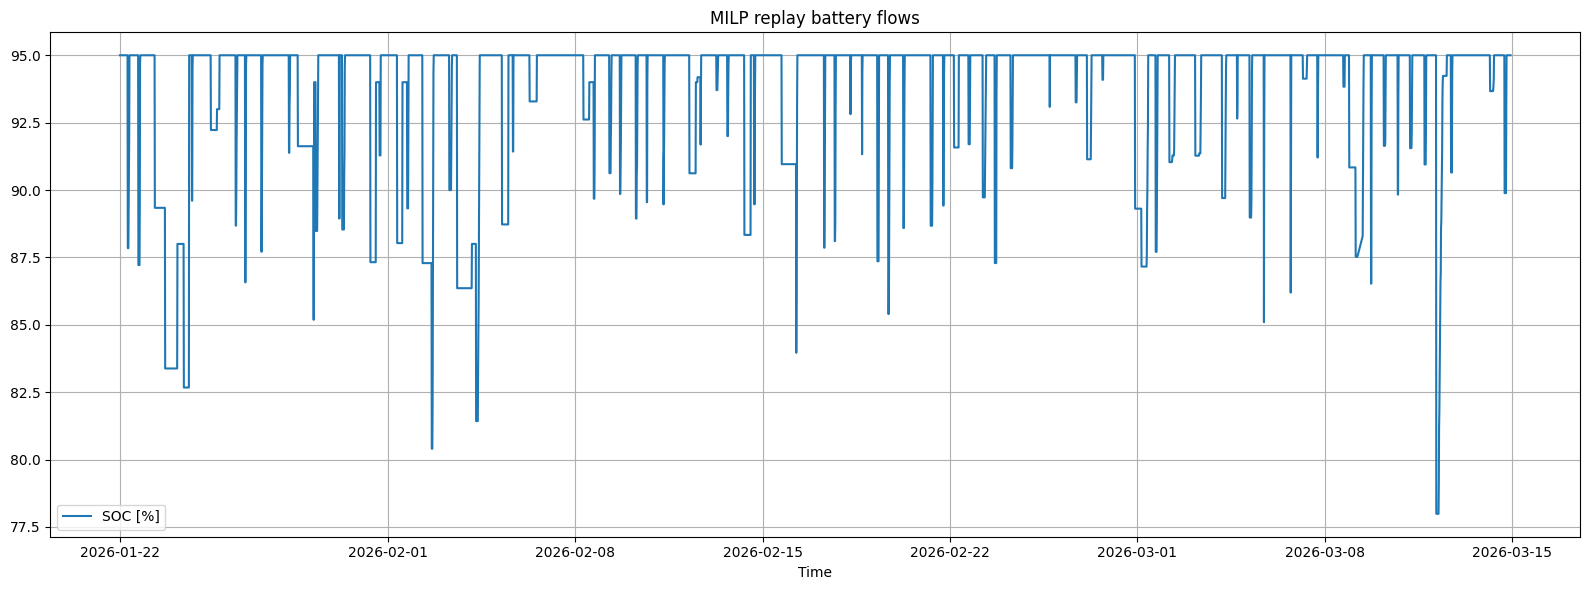

In [29]:
import matplotlib.pyplot as plt

def plot_milp_battery_flows(milp_15: pd.DataFrame, start=None, end=None):
    df = milp_15.copy()
    if start is not None:
        df = df[df.index >= pd.to_datetime(start)]
    if end is not None:
        df = df[df.index <= pd.to_datetime(end)]

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(df.index, df["milp_soc_percent"], label="SOC [%]")

    ax.set_title("MILP replay battery flows")
    ax.set_xlabel("Time")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()
plot_milp_battery_flows(milp_15, start = "2026-01-22",
end = "2026-03-15")

In [13]:
def replay_milp_daily_plan(
    resampled_15: pd.DataFrame,
    df_spot: pd.DataFrame,
    milp_schedule: pd.DataFrame,
    initial_soc_percent: float,
    capacity_kwh: float = 14.4,
    min_percent: float = 20.0,
    max_percent: float = 95.0,
    max_charge_kw: float = 9.8,
    max_discharge_kw: float = 9.8,
) -> pd.DataFrame:
    merged = (
        df_spot.copy()
        .join(resampled_15[["P_HOME", "P_PV", "P_BAT", "raw_points", "low_coverage"]], how="left")
        .join(
            milp_schedule[
                ["charge_allowed", "discharge_allowed", "charge_session_id", "target_soc_percent"]
            ],
            how="left",
        )
    )

    merged["charge_allowed"] = merged["charge_allowed"].fillna(False)
    merged["discharge_allowed"] = merged["discharge_allowed"].fillna(False)

    merged = merged.dropna(subset=["P_HOME", "P_BAT", "P_PV", "spot_price"])

    dt = 0.25
    soc_kwh = capacity_kwh * initial_soc_percent / 100.0
    min_kwh = capacity_kwh * min_percent / 100.0
    max_kwh = capacity_kwh * max_percent / 100.0

    rows = []

    for ts, row in merged.iterrows():
        home_kw = float(row["P_HOME"]) - float(row["P_BAT"])
        pv_kw = float(row["P_PV"])
        price = float(row["spot_price"])

        charge_allowed = bool(row["charge_allowed"])
        discharge_allowed = bool(row["discharge_allowed"])

        target_soc_percent = row["target_soc_percent"]
        target_soc_kwh = None
        if pd.notna(target_soc_percent):
            target_soc_kwh = capacity_kwh * float(target_soc_percent) / 100.0
            target_soc_kwh = min(max(target_soc_kwh, min_kwh), max_kwh)

        surplus_kw = max(pv_kw - home_kw, 0.0)
        deficit_kw = max(home_kw - pv_kw, 0.0)

        free_room_kw = max((max_kwh - soc_kwh) / dt, 0.0)
        available_discharge_kw = max((soc_kwh - min_kwh) / dt, 0.0)

        # 1) PV surplus always charges battery first
        executed_pv_charge = min(surplus_kw, max_charge_kw, free_room_kw)

        # 2) Grid charging only if MILP allows it and target is not reached
        executed_grid_charge = 0.0
        if charge_allowed and target_soc_kwh is not None and soc_kwh < target_soc_kwh:
            remaining_to_target_kw = max((target_soc_kwh - soc_kwh) / dt, 0.0)

            remaining_charge_headroom_kw = max(max_charge_kw - executed_pv_charge, 0.0)
            remaining_free_room_kw = max((max_kwh - soc_kwh) / dt - executed_pv_charge, 0.0)

            executed_grid_charge = min(
                remaining_to_target_kw,
                remaining_charge_headroom_kw,
                remaining_free_room_kw,
            )

        # 3) Discharge only covers deficit after PV
        executed_discharge = 0.0
        if discharge_allowed:
            executed_discharge = min(
                max_discharge_kw,
                deficit_kw,
                available_discharge_kw,
            )

        # Grid exchange
        net_grid_kw = home_kw + executed_grid_charge + executed_pv_charge - pv_kw - executed_discharge

        grid_buy_kwh = max(net_grid_kw, 0.0) * dt
        grid_sell_kwh = max(-net_grid_kw, 0.0) * dt

        # SOC update
        soc_kwh = soc_kwh + (executed_pv_charge + executed_grid_charge - executed_discharge) * dt
        soc_kwh = min(max(soc_kwh, min_kwh), max_kwh)

        milp_cost = (grid_buy_kwh - grid_sell_kwh) * price

        rows.append({
            "DateTime": ts,
            "milp_grid_buy_kwh": grid_buy_kwh,
            "milp_grid_sell_kwh": grid_sell_kwh,
            "milp_exec_pv_charge_kw": executed_pv_charge,
            "milp_exec_grid_charge_kw": executed_grid_charge,
            "milp_exec_discharge_kw": executed_discharge,
            "milp_soc_percent": soc_kwh * 100.0 / capacity_kwh,
            "milp_cost": milp_cost,
        })

    return pd.DataFrame(rows).set_index("DateTime")

In [14]:
def build_daily_comparison(actual_df, nobatt_df, milp_df) -> pd.DataFrame:
    daily = pd.DataFrame({
        "actual_cost": actual_df["actual_cost"].resample("1D").sum(),
        "no_battery_cost": nobatt_df["nobatt_cost"].resample("1D").sum(),
        "milp_cost": milp_df["milp_cost"].resample("1D").sum(),
    })

    daily["battery_actual_saving"] = daily["no_battery_cost"] - daily["actual_cost"]
    daily["milp_vs_actual_saving"] = daily["actual_cost"] - daily["milp_cost"]
    daily["milp_vs_nobatt_saving"] = daily["no_battery_cost"] - daily["milp_cost"]

    return daily

In [15]:
def compute_no_battery_cost_from_resampled(resampled_15: pd.DataFrame, df_spot: pd.DataFrame) -> pd.DataFrame:
    spot = df_spot.copy()
    spot["spot_price"] = (
        spot["spot_price"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    out = spot.join(resampled_15[["P_HOME", "P_PV", "raw_points", "low_coverage", "P_BAT"]], how="left")
    out = out.dropna(subset=["P_HOME", "P_PV", "spot_price"])

    dt = 0.25
    net_kwh = (out["P_HOME"] - out["P_BAT"] - out["P_PV"]) * dt

    out["nobatt_buy_kwh"] = net_kwh.clip(lower=0)
    out["nobatt_sell_kwh"] = (-net_kwh).clip(lower=0)
    out["nobatt_cost"] = (out["nobatt_buy_kwh"] - out["nobatt_sell_kwh"]) * out["spot_price"]

    return out

In [16]:
import pandas as pd
import numpy as np

def compute_actual_cost_from_cumulative_prorated(
    df_actual: pd.DataFrame,
    df_spot: pd.DataFrame,
    max_interval_minutes: int = 60,
) -> pd.DataFrame:
    df = df_actual.copy().sort_index()
    spot = df_spot.copy().sort_index()

    for col in ["BUY_T", "SELL_T"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

    spot["spot_price"] = (
        spot["spot_price"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    # Build 15-minute output frame from spot timeline
    out = spot.copy()
    out["buy_kwh"] = 0.0
    out["sell_kwh"] = 0.0

    prev_time = None
    prev_buy = None
    prev_sell = None

    for ts, row in df.iterrows():
        buy_t = row["BUY_T"]
        sell_t = row["SELL_T"]

        if prev_time is None:
            prev_time = ts
            prev_buy = buy_t
            prev_sell = sell_t
            continue

        if pd.isna(buy_t) or pd.isna(sell_t) or pd.isna(prev_buy) or pd.isna(prev_sell):
            prev_time = ts
            prev_buy = buy_t
            prev_sell = sell_t
            continue

        delta_buy = buy_t - prev_buy
        delta_sell = sell_t - prev_sell
        interval_min = (ts - prev_time).total_seconds() / 60.0

        # skip resets / bad jumps / absurdly long gaps
        if interval_min <= 0 or interval_min > max_interval_minutes:
            prev_time = ts
            prev_buy = buy_t
            prev_sell = sell_t
            continue

        if delta_buy < 0 or delta_sell < 0:
            prev_time = ts
            prev_buy = buy_t
            prev_sell = sell_t
            continue

        interval_start = prev_time
        interval_end = ts
        total_seconds = (interval_end - interval_start).total_seconds()

        # affected 15-minute bins
        bin_start = interval_start.floor("15min")
        bin_end = interval_end.floor("15min")

        bins = pd.date_range(bin_start, bin_end, freq="15min")

        for b in bins:
            b_start = b
            b_end = b + pd.Timedelta(minutes=15)

            overlap_start = max(interval_start, b_start)
            overlap_end = min(interval_end, b_end)

            overlap_seconds = (overlap_end - overlap_start).total_seconds()

            if overlap_seconds <= 0:
                continue

            weight = overlap_seconds / total_seconds

            if b in out.index:
                out.at[b, "buy_kwh"] += delta_buy * weight
                out.at[b, "sell_kwh"] += delta_sell * weight

        prev_time = ts
        prev_buy = buy_t
        prev_sell = sell_t

    out["actual_cost"] = (out["buy_kwh"] - out["sell_kwh"]) * out["spot_price"]
    return out

In [43]:
import sqlite3
import pandas as pd

def load_predicted_daily_cost(db_path: str, table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)

    df = pd.read_sql_query(
        f"""
        SELECT
            TimeStamp,
            PriceSum
        FROM {table_name}
        ORDER BY TimeStamp
        """,
        conn,
    )
    conn.close()

    df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])
    df = df.set_index("TimeStamp").sort_index()

    df["PriceSum"] = (
        df["PriceSum"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    return df.rename(columns={"PriceSum": "predicted_cost"})

In [44]:
predicted_daily = load_predicted_daily_cost("FVEDB.db", "PredictedControlData")
predicted_daily.head()

,predicted_cost
TimeStamp,
2026-01-22,218.325974
2026-01-23,252.752777
2026-01-24,191.529007
2026-01-25,173.052536
2026-01-26,206.547348


In [19]:
milp_daily = load_milp_daily_plan("FVEDB.db", "PredictedControlData")
milp_schedule = expand_milp_daily_plan(milp_daily)
milp_15 = replay_milp_daily_plan(
    resampled_15=resampled_15,
    df_spot=spot,
    milp_schedule=milp_schedule,
    initial_soc_percent=20.0,
)
milp_15.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_12132\2050545874.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["charge_allowed"] = merged["charge_allowed"].fillna(False)
C:\Users\hp\AppData\Local\Temp\ipykernel_12132\2050545874.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["discharge_allowed"] = merged["discharge_allowed"].fillna(False)


,milp_grid_buy_kwh,milp_grid_sell_kwh,milp_exec_pv_charge_kw,milp_exec_grid_charge_kw,milp_exec_discharge_kw,milp_soc_percent,milp_cost
DateTime,,,,,,,
2025-11-01 00:00:00,0.0,-0.0,0.0,0.0,0.0,20.0,0.0
2025-11-01 00:15:00,0.0,-0.0,0.0,0.0,0.0,20.0,0.0
2025-11-01 00:30:00,0.0,-0.0,0.0,0.0,0.0,20.0,0.0
2025-11-01 00:45:00,0.0,-0.0,0.0,0.0,0.0,20.0,0.0
2025-11-01 01:00:00,0.0,-0.0,0.0,0.0,0.0,20.0,0.0


In [18]:
actual_raw = load_actual_data("FVEDB.db", "MqttData")
spot = load_spot_data("FVEDB.db", "SpotData")
# milp = load_milp_prediction("FVEDB.db", "PredictedControlData")

# resampled_15 = resample_house_to_15min_safe(actual_raw, max_interp_minutes=30)
resampled_15, minute_clean = resample_house_to_15min_gap_aware(
    actual_raw,
    max_gap_minutes=30,
    clip_home_kw=12,
    clip_pv_kw=12,
    clip_bat_kw=10,
)
actual_cost_15 = compute_actual_cost_from_cumulative_prorated(
    actual_raw,
    spot,
    max_interval_minutes=60,
)
# actual_cost_15 = compute_actual_cost_from_cumulative_safe(actual_raw, spot)
# nobatt_15 = compute_no_battery_cost(actual_raw, spot)
nobatt_15 = compute_no_battery_cost_from_resampled(resampled_15, spot)



NameError: name 'milp_15' is not defined

In [21]:
daily = build_daily_comparison(actual_cost_15, nobatt_15, milp_15)
daily

,actual_cost,no_battery_cost,milp_cost,battery_actual_saving,milp_vs_actual_saving,milp_vs_nobatt_saving
DateTime,,,,,,
2025-11-01,35.200268,-20.494551,-15.644415,-55.694820,50.844683,-4.850137
2025-11-02,100.644247,-3.575488,-3.575488,-104.219735,104.219735,0.000000
2025-11-03,88.545332,-6.893960,-6.893960,-95.439292,95.439292,0.000000
2025-11-04,89.701465,-27.272679,-27.272679,-116.974143,116.974143,0.000000
2025-11-05,46.265786,-67.760513,-67.760513,-114.026299,114.026299,0.000000
...,...,...,...,...,...,...
2026-04-03,64.657826,56.642489,56.642489,-8.015337,8.015337,0.000000
2026-04-04,55.243127,48.692556,48.692556,-6.550570,6.550570,0.000000
2026-04-05,3.934104,1.810416,1.810416,-2.123688,2.123688,0.000000


In [122]:
nobatt_15 = compute_no_battery_cost_from_resampled(resampled_15, spot)


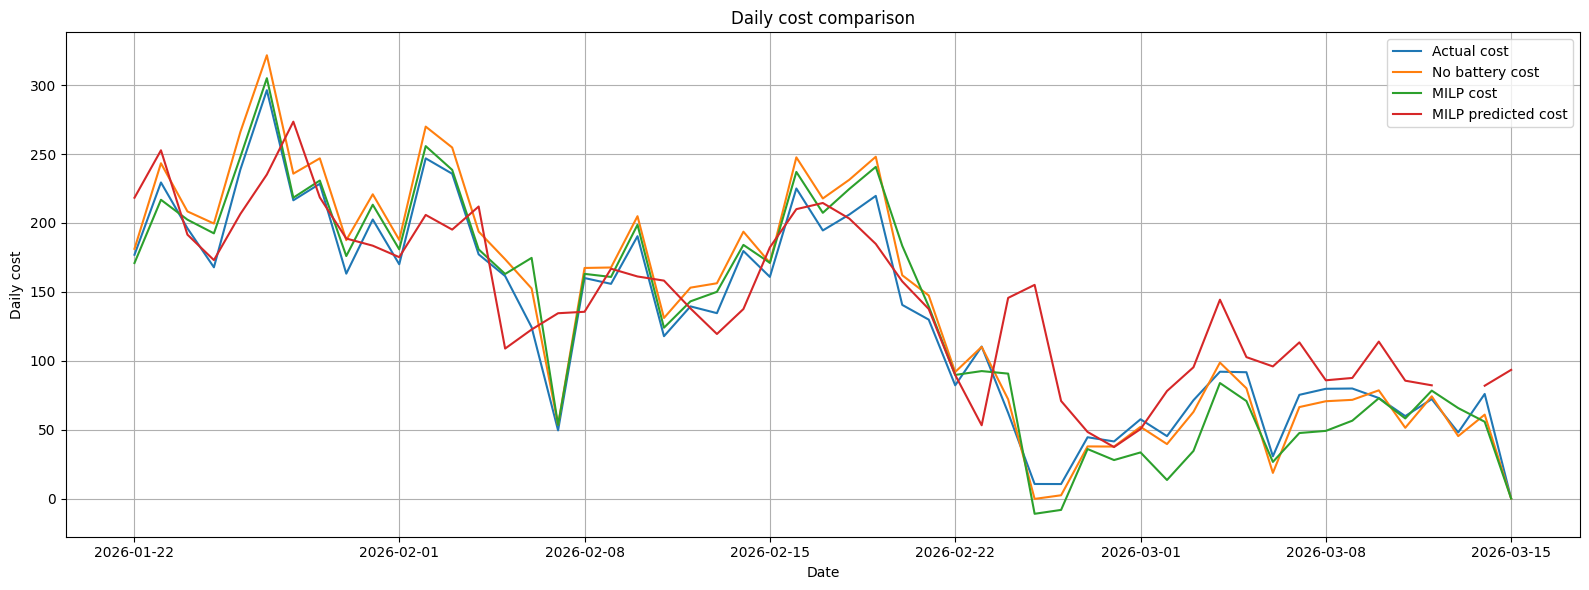

In [55]:
def plot_daily_costs(daily: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(daily.index, daily["actual_cost"], label="Actual cost")
    ax.plot(daily.index, daily["no_battery_cost"], label="No battery cost")
    ax.plot(daily.index, daily["milp_cost"], label="MILP cost")
    ax.plot(daily.index, daily["predicted_cost"], label="MILP predicted cost")

    ax.set_title("Daily cost comparison")
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily cost")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

start = "2026-01-22"
end = "2026-03-15"

daily = pd.DataFrame({
    "actual_cost": actual_cost_15["actual_cost"].resample("1D").sum(),
    "no_battery_cost": nobatt_15["nobatt_cost"].resample("1D").sum(),
    "milp_cost": milp_15["milp_cost"].resample("1D").sum(),
}).join(
    predicted_daily[["predicted_cost"]],
    how="left"
)

daily["battery_actual_saving"] = daily["no_battery_cost"] - daily["actual_cost"]
daily["milp_vs_actual_saving"] = daily["actual_cost"] - daily["milp_cost"]
daily["milp_vs_nobatt_saving"] = daily["no_battery_cost"] - daily["milp_cost"]

daily["predicted_vs_actual_diff"] = daily["predicted_cost"] - daily["actual_cost"]
daily["predicted_vs_milp_replay_diff"] = daily["predicted_cost"] - daily["milp_cost"]

daily_range = daily.loc[start:end].copy()
plot_daily_costs(daily_range)

In [99]:
daily = pd.DataFrame({
    "actual_cost": actual_cost_15["actual_cost"].resample("1D").sum(),
    "no_battery_cost": nobatt_15["nobatt_cost"].resample("1D").sum(),
    "milp_cost": milp_15["milp_cost"].resample("1D").sum(),
})

daily["battery_actual_saving"] = daily["no_battery_cost"] - daily["actual_cost"]
daily["milp_vs_actual_saving"] = daily["actual_cost"] - daily["milp_cost"]
daily["milp_vs_nobatt_saving"] = daily["no_battery_cost"] - daily["milp_cost"]

daily

,actual_cost,no_battery_cost,milp_cost,battery_actual_saving,milp_vs_actual_saving,milp_vs_nobatt_saving
DateTime,,,,,,
2025-11-01,35.200268,-13.415194,-13.415194,-48.615462,48.615462,0.0
2025-11-02,100.644247,-3.559188,-3.559188,-104.203435,104.203435,0.0
2025-11-03,88.545332,-6.980055,-6.980055,-95.525387,95.525387,0.0
2025-11-04,89.701465,-28.494401,-28.494401,-118.195866,118.195866,0.0
2025-11-05,46.265786,-60.124360,-60.124360,-106.390146,106.390146,0.0
...,...,...,...,...,...,...
2026-04-03,64.657826,77.121640,77.121640,12.463814,-12.463814,0.0
2026-04-04,55.243127,61.700189,61.700189,6.457062,-6.457062,0.0
2026-04-05,3.934104,7.000667,7.000667,3.066563,-3.066563,0.0


In [52]:
milp_15_range = milp_15.loc["2026-01-22":"2026-02-20"].copy()
milp_daily_use = pd.DataFrame({
    "pv_charge_kwh": (milp_15_range["milp_exec_pv_charge_kw"] * 0.25).resample("1D").sum(),
    "grid_charge_kwh": (milp_15_range["milp_exec_grid_charge_kw"] * 0.25).resample("1D").sum(),
    "discharge_kwh": (milp_15_range["milp_exec_discharge_kw"] * 0.25).resample("1D").sum(),
    "end_soc": milp_15_range["milp_soc_percent"].resample("1D").last(),
}).round(2)

display(milp_daily_use)

,pv_charge_kwh,grid_charge_kwh,discharge_kwh,end_soc
DateTime,,,,
2026-01-22,2.29,12.98,15.27,20.00
2026-01-23,0.00,19.58,19.58,20.00
2026-01-24,0.00,20.59,20.59,20.00
2026-01-25,0.00,19.63,19.63,20.00
2026-01-26,0.00,20.45,20.45,20.00
2026-01-27,0.00,20.30,20.30,20.00
2026-01-28,0.16,18.30,18.46,20.00
2026-01-29,0.00,12.25,12.25,20.00
2026-01-30,0.00,12.28,12.28,20.00


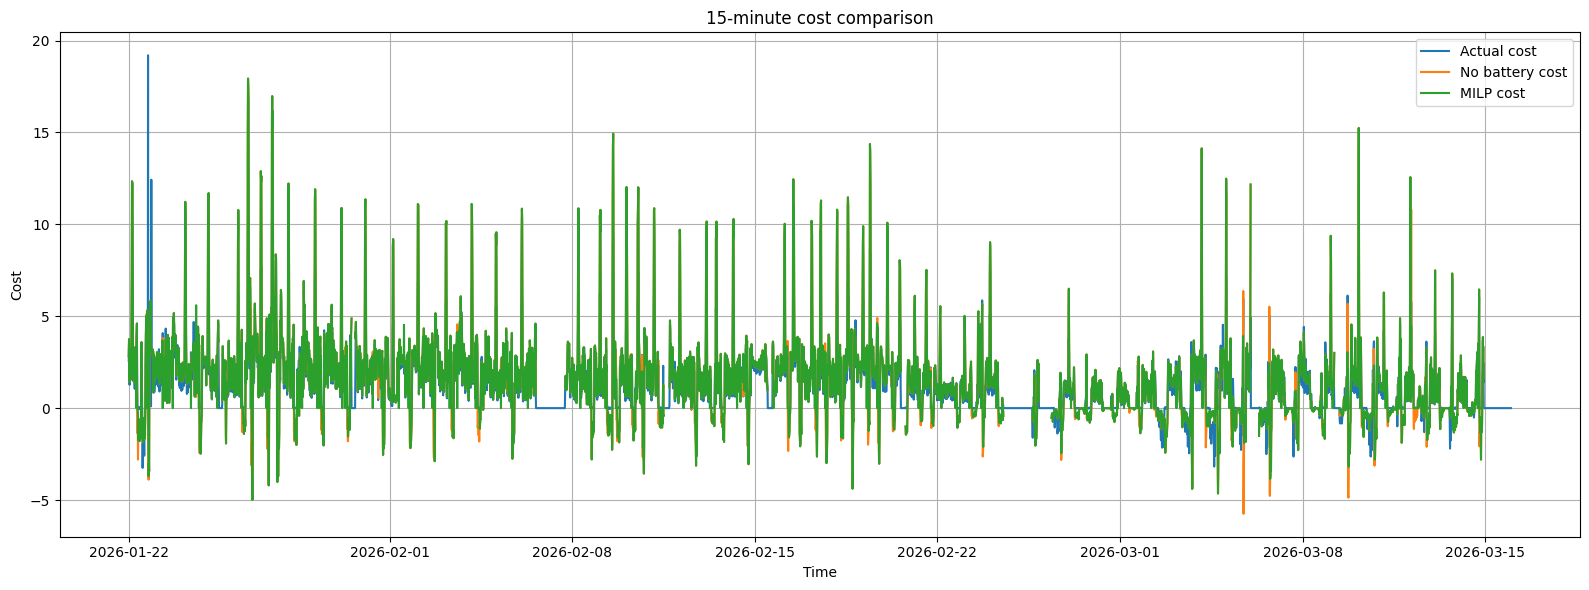

In [23]:
import matplotlib.pyplot as plt

def plot_costs_with_milp(actual_cost_15, nobatt_15, milp_15, start=None, end=None):
    df = (
        actual_cost_15[["actual_cost"]]
        .join(nobatt_15[["nobatt_cost"]], how="outer")
        .join(milp_15[["milp_cost"]], how="outer")
        .sort_index()
    )

    if start is not None:
        df = df[df.index >= pd.to_datetime(start)]
    if end is not None:
        df = df[df.index <= pd.to_datetime(end)]

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(df.index, df["actual_cost"], label="Actual cost")
    ax.plot(df.index, df["nobatt_cost"], label="No battery cost")
    ax.plot(df.index, df["milp_cost"], label="MILP cost")
    ax.set_title("15-minute cost comparison")
    ax.set_xlabel("Time")
    ax.set_ylabel("Cost")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_costs_with_milp(
    actual_cost_15,
    nobatt_15,
    milp_15,
    start="2026-01-22 00:00:00",
    end="2026-03-15 23:59:59",
)

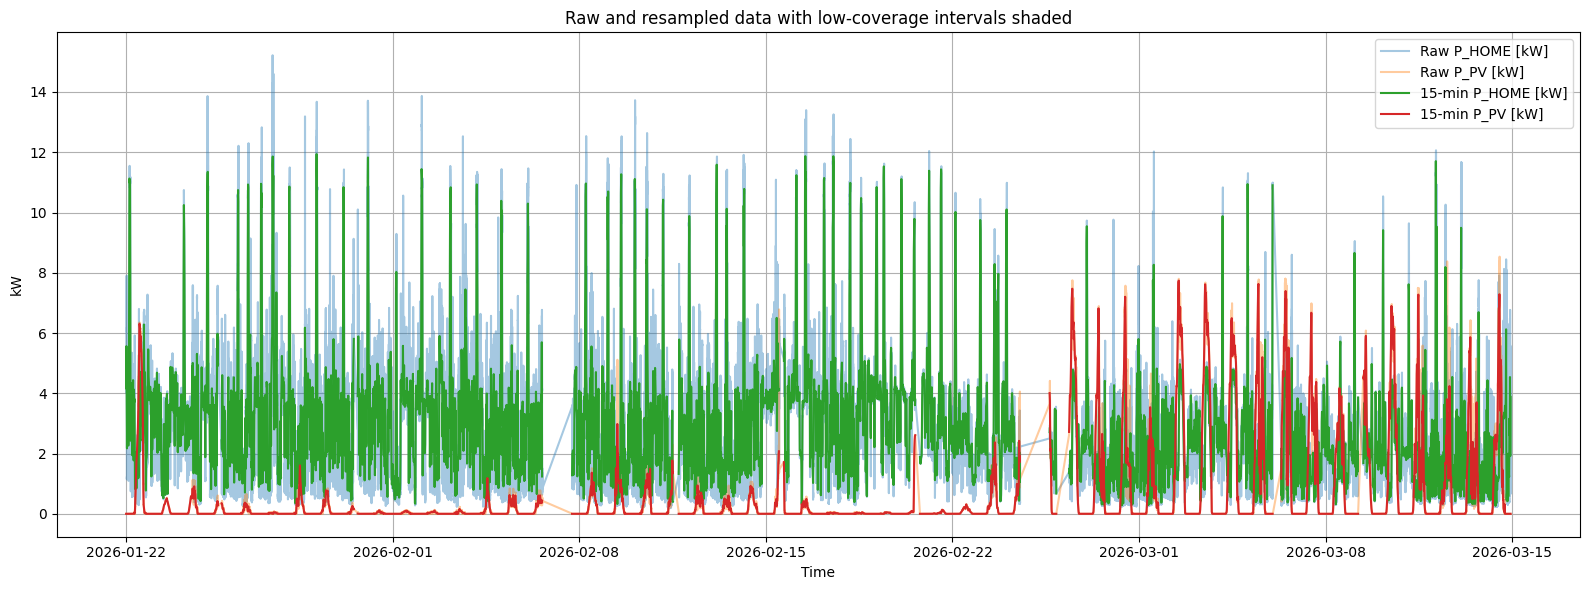

In [25]:
import matplotlib.pyplot as plt

def plot_raw_with_gaps(resampled_15: pd.DataFrame, actual_raw: pd.DataFrame, start=None, end=None):
    raw = actual_raw.copy()
    rs = resampled_15.copy()

    if start is not None:
        start = pd.to_datetime(start)
        raw = raw[raw.index >= start]
        rs = rs[rs.index >= start]
    if end is not None:
        end = pd.to_datetime(end)
        raw = raw[raw.index <= end]
        rs = rs[rs.index <= end]

    fig, ax = plt.subplots(figsize=(16, 6))

    if "P_HOME" in raw.columns:
        raw_home = pd.to_numeric(raw["P_HOME"].astype(str).str.replace(",", ".", regex=False), errors="coerce") / 1000.0
        ax.plot(raw.index, raw_home, label="Raw P_HOME [kW]", alpha=0.4)

    if "P_PV" in raw.columns:
        raw_pv = pd.to_numeric(raw["P_PV"].astype(str).str.replace(",", ".", regex=False), errors="coerce") / 1000.0
        ax.plot(raw.index, raw_pv, label="Raw P_PV [kW]", alpha=0.4)

    if "P_HOME" in rs.columns:
        ax.plot(rs.index, rs["P_HOME"], label="15-min P_HOME [kW]")
    if "P_PV" in rs.columns:
        ax.plot(rs.index, rs["P_PV"], label="15-min P_PV [kW]")

    # mark bad coverage bins
    if "low_coverage_home" in rs.columns:
        bad = rs["low_coverage_home"].fillna(False)
        for ts in rs.index[bad]:
            ax.axvspan(ts, ts + pd.Timedelta(minutes=15), alpha=0.12)

    ax.set_title("Raw and resampled data with low-coverage intervals shaded")
    ax.set_xlabel("Time")
    ax.set_ylabel("kW")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()
plot_raw_with_gaps(
    resampled_15=resampled_15,
    actual_raw=actual_raw,
    start="2026-01-22 00:00:00",
    end="2026-03-15 23:59:59",
)

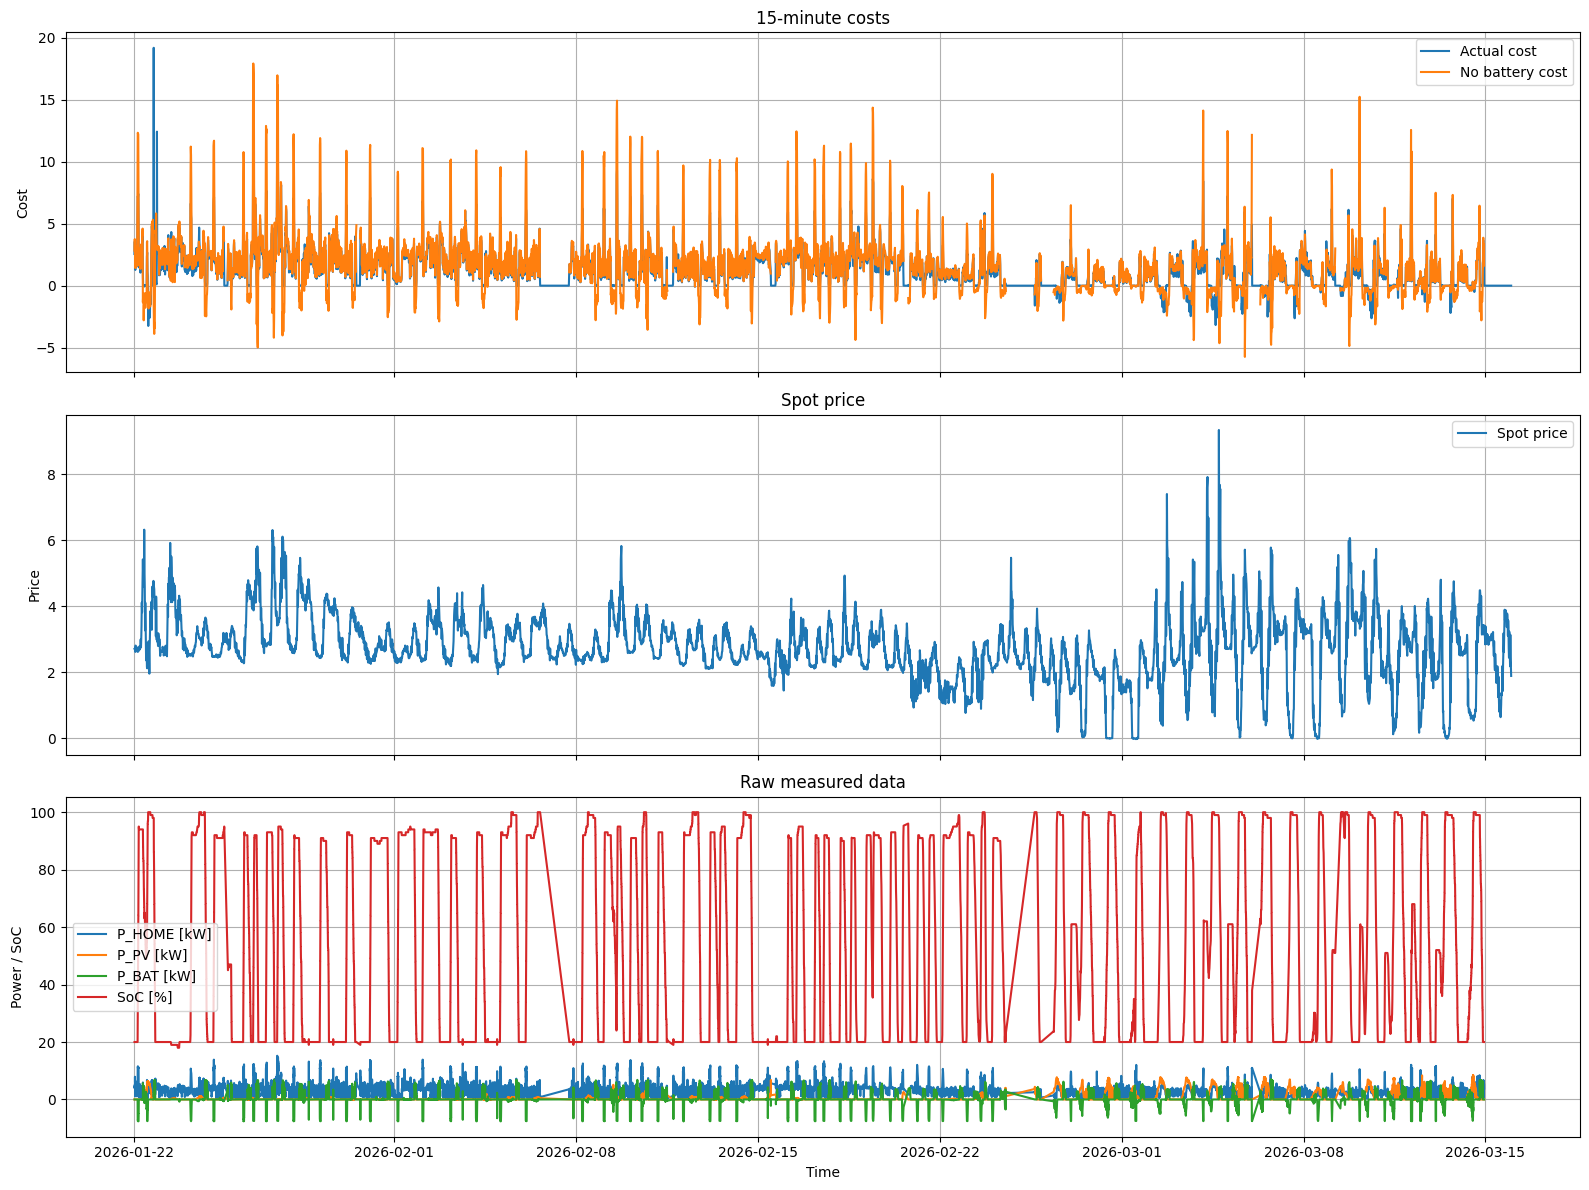

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_actual_nobatt_spot_raw(
    actual_cost_15: pd.DataFrame,
    nobatt_15: pd.DataFrame,
    spot: pd.DataFrame,
    actual_raw: pd.DataFrame,
    start=None,
    end=None,
):
    # Copy
    actual_cost = actual_cost_15.copy()
    nobatt = nobatt_15.copy()
    spot_df = spot.copy()
    raw = actual_raw.copy()

    # Optional time filter
    if start is not None:
        start = pd.to_datetime(start)
        actual_cost = actual_cost[actual_cost.index >= start]
        nobatt = nobatt[nobatt.index >= start]
        spot_df = spot_df[spot_df.index >= start]
        raw = raw[raw.index >= start]

    if end is not None:
        end = pd.to_datetime(end)
        actual_cost = actual_cost[actual_cost.index <= end]
        nobatt = nobatt[nobatt.index <= end]
        spot_df = spot_df[spot_df.index <= end]
        raw = raw[raw.index <= end]

    # Ensure numeric raw columns
    for col in ["P_HOME", "P_PV", "P_BAT", "SoC"]:
        if col in raw.columns:
            raw[col] = (
                raw[col]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .pipe(pd.to_numeric, errors="coerce")
            )

    # Build figure
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    # 1) 15-min costs
    cost_df = actual_cost[["actual_cost"]].join(
        nobatt[["nobatt_cost"]],
        how="outer"
    ).sort_index()

    axes[0].plot(cost_df.index, cost_df["actual_cost"], label="Actual cost")
    axes[0].plot(cost_df.index, cost_df["nobatt_cost"], label="No battery cost")
    axes[0].set_title("15-minute costs")
    axes[0].set_ylabel("Cost")
    axes[0].grid(True)
    axes[0].legend()

    # 2) Spot
    spot_col = "spot_price"
    if spot_col not in spot_df.columns:
        raise ValueError(f"Expected column '{spot_col}' in spot dataframe.")

    spot_df[spot_col] = (
        spot_df[spot_col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    axes[1].plot(spot_df.index, spot_df[spot_col], label="Spot price")
    axes[1].set_title("Spot price")
    axes[1].set_ylabel("Price")
    axes[1].grid(True)
    axes[1].legend()

    # 3) Raw data
    if "P_HOME" in raw.columns:
        axes[2].plot(raw.index, raw["P_HOME"] / 1000.0, label="P_HOME [kW]")
    if "P_PV" in raw.columns:
        axes[2].plot(raw.index, raw["P_PV"] / 1000.0, label="P_PV [kW]")
    if "P_BAT" in raw.columns:
        axes[2].plot(raw.index, raw["P_BAT"] / 1000.0, label="P_BAT [kW]")
    if "SoC" in raw.columns:
        axes[2].plot(raw.index, raw["SoC"], label="SoC [%]")

    axes[2].set_title("Raw measured data")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Power / SoC")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_actual_nobatt_spot_raw(
    actual_cost_15=actual_cost_15,
    nobatt_15=nobatt_15,
    spot=spot,
    actual_raw=actual_raw,
    start="2026-01-22 00:00:00",
    end="2026-03-15 23:59:59",
)

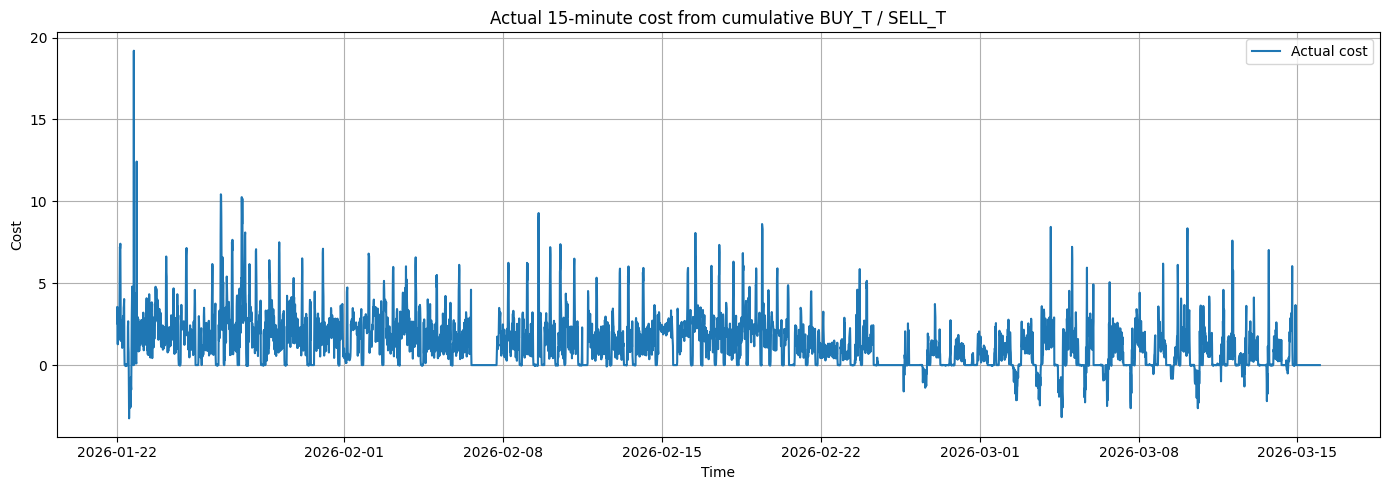

In [27]:
import matplotlib.pyplot as plt

def plot_actual_cost(actual_cost_15: pd.DataFrame, start=None, end=None):
    df = actual_cost_15.copy()

    if start is not None:
        df = df[df.index >= pd.to_datetime(start)]
    if end is not None:
        df = df[df.index <= pd.to_datetime(end)]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df.index, df["actual_cost"], label="Actual cost")
    ax.set_title("Actual 15-minute cost from cumulative BUY_T / SELL_T")
    ax.set_xlabel("Time")
    ax.set_ylabel("Cost")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()
plot_actual_cost(actual_cost_15,
                     start="2026-01-22 00:00:00",
    end="2026-03-15 23:59:59",
)

In [30]:
def expand_milp_daily_plan_to_mode_changes(milp_daily: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, day in milp_daily.iterrows():
        charge_times = sorted(pd.to_datetime(day["ChargeTimes"]))
        discharge_times = sorted(pd.to_datetime(day["DischargeTimes"]))
        targets = [float(x) for x in day["ChargeToCapacities"]]

        # group charge times into contiguous sessions
        charge_sessions = []
        if charge_times:
            current = [charge_times[0]]
            for t in charge_times[1:]:
                if (t - current[-1]) == pd.Timedelta(minutes=15):
                    current.append(t)
                else:
                    charge_sessions.append(current)
                    current = [t]
            charge_sessions.append(current)

        # group discharge times into contiguous sessions
        discharge_sessions = []
        if discharge_times:
            current = [discharge_times[0]]
            for t in discharge_times[1:]:
                if (t - current[-1]) == pd.Timedelta(minutes=15):
                    current.append(t)
                else:
                    discharge_sessions.append(current)
                    current = [t]
            discharge_sessions.append(current)

        # charge session starts
        for i, sess in enumerate(charge_sessions):
            if len(targets) == 0:
                target = None
            elif i < len(targets):
                target = targets[i]
            else:
                target = targets[-1]

            rows.append({
                "DateTime": sess[0],
                "mode": "charge",
                "target_soc_percent": target,
            })

        # discharge session starts
        for sess in discharge_sessions:
            rows.append({
                "DateTime": sess[0],
                "mode": "discharge",
                "target_soc_percent": None,
            })

    out = pd.DataFrame(rows)
    out["DateTime"] = pd.to_datetime(out["DateTime"])
    return out.sort_values("DateTime").set_index("DateTime")

In [31]:
def replay_milp_state_machine(
    resampled_15: pd.DataFrame,
    df_spot: pd.DataFrame,
    milp_mode_changes: pd.DataFrame,
    actual_raw: pd.DataFrame,
    capacity_kwh: float = 14.4,
    min_percent: float = 20.0,
    max_percent: float = 95.0,
    max_charge_kw: float = 9.8,
    max_discharge_kw: float = 9.8,
) -> pd.DataFrame:
    # real initial SoC per day
    raw_soc = actual_raw.copy()
    raw_soc["SoC"] = (
        raw_soc["SoC"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )
    daily_initial_soc = raw_soc["SoC"].resample("1D").first()

    all_rows = []

    for day_start, initial_soc_percent in daily_initial_soc.dropna().items():
        day_end = day_start + pd.Timedelta(days=1)

        rs_day = resampled_15.loc[(resampled_15.index >= day_start) & (resampled_15.index < day_end)]
        spot_day = df_spot.loc[(df_spot.index >= day_start) & (df_spot.index < day_end)]
        mode_day = milp_mode_changes.loc[(milp_mode_changes.index >= day_start) & (milp_mode_changes.index < day_end)]

        if rs_day.empty or spot_day.empty:
            continue

        merged = (
            spot_day.copy()
            .join(rs_day[["P_HOME", "P_PV", "raw_points", "low_coverage"]], how="left")
            .join(mode_day[["mode", "target_soc_percent"]], how="left")
        )

        merged = merged.dropna(subset=["P_HOME", "P_PV", "spot_price"])

        dt = 0.25
        soc_kwh = capacity_kwh * float(initial_soc_percent) / 100.0
        min_kwh = capacity_kwh * min_percent / 100.0
        max_kwh = capacity_kwh * max_percent / 100.0

        current_mode = None
        current_target_soc_kwh = None

        rows = []

        for ts, row in merged.iterrows():
            home_kw = float(row["P_HOME"])
            pv_kw = float(row["P_PV"])
            price = float(row["spot_price"])

            # update mode only when a mode-change point appears
            if pd.notna(row.get("mode")):
                current_mode = row["mode"]
                if current_mode == "charge" and pd.notna(row.get("target_soc_percent")):
                    current_target_soc_kwh = capacity_kwh * float(row["target_soc_percent"]) / 100.0
                    current_target_soc_kwh = min(max(current_target_soc_kwh, min_kwh), max_kwh)
                else:
                    current_target_soc_kwh = None

            surplus_kw = max(pv_kw - home_kw, 0.0)
            deficit_kw = max(home_kw - pv_kw, 0.0)

            free_room_kw = max((max_kwh - soc_kwh) / dt, 0.0)
            available_discharge_kw = max((soc_kwh - min_kwh) / dt, 0.0)

            # PV surplus always charges first
            executed_pv_charge = min(surplus_kw, max_charge_kw, free_room_kw)

            executed_grid_charge = 0.0
            executed_discharge = 0.0

            if current_mode == "charge":
                # stay charging until target reached or mode changes later
                if current_target_soc_kwh is not None and soc_kwh < current_target_soc_kwh:
                    remaining_to_target_kw = max((current_target_soc_kwh - soc_kwh) / dt, 0.0)
                    remaining_charge_headroom_kw = max(max_charge_kw - executed_pv_charge, 0.0)
                    remaining_free_room_kw = max((max_kwh - soc_kwh) / dt - executed_pv_charge, 0.0)

                    executed_grid_charge = min(
                        remaining_to_target_kw,
                        remaining_charge_headroom_kw,
                        remaining_free_room_kw,
                    )
                else:
                    # target reached, stop charging until next mode change
                    if current_target_soc_kwh is not None and soc_kwh >= current_target_soc_kwh:
                        current_mode = None

            elif current_mode == "discharge":
                # stay discharging until minimum reached or mode changes later
                executed_discharge = min(
                    max_discharge_kw,
                    deficit_kw,
                    available_discharge_kw,
                )

                if soc_kwh <= min_kwh + 1e-9:
                    current_mode = None

            # grid exchange
            net_grid_kw = home_kw + executed_grid_charge + executed_pv_charge - pv_kw - executed_discharge

            grid_buy_kwh = max(net_grid_kw, 0.0) * dt
            grid_sell_kwh = max(-net_grid_kw, 0.0) * dt

            # update SOC
            soc_kwh = soc_kwh + (executed_pv_charge + executed_grid_charge - executed_discharge) * dt
            soc_kwh = min(max(soc_kwh, min_kwh), max_kwh)

            milp_cost = (grid_buy_kwh - grid_sell_kwh) * price

            rows.append({
                "DateTime": ts,
                "milp_mode": current_mode,
                "milp_grid_buy_kwh": grid_buy_kwh,
                "milp_grid_sell_kwh": grid_sell_kwh,
                "milp_exec_pv_charge_kw": executed_pv_charge,
                "milp_exec_grid_charge_kw": executed_grid_charge,
                "milp_exec_discharge_kw": executed_discharge,
                "milp_soc_percent": soc_kwh * 100.0 / capacity_kwh,
                "milp_cost": milp_cost,
            })

        all_rows.extend(rows)

    return pd.DataFrame(all_rows).set_index("DateTime").sort_index()

In [53]:
def replay_milp_state_machine(
    resampled_15: pd.DataFrame,
    df_spot: pd.DataFrame,
    milp_mode_changes: pd.DataFrame,
    actual_raw: pd.DataFrame,
    capacity_kwh: float = 14.4,
    min_percent: float = 20.0,
    max_percent: float = 95.0,
    max_charge_kw: float = 9.8,
    max_discharge_kw: float = 9.8,
) -> pd.DataFrame:
    # real initial SoC per day
    raw_soc = actual_raw.copy()
    raw_soc["SoC"] = (
        raw_soc["SoC"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )
    daily_initial_soc = raw_soc["SoC"].resample("1D").first()

    all_rows = []

    for day_start, initial_soc_percent in daily_initial_soc.dropna().items():
        day_end = day_start + pd.Timedelta(days=1)

        rs_day = resampled_15.loc[(resampled_15.index >= day_start) & (resampled_15.index < day_end)]
        spot_day = df_spot.loc[(df_spot.index >= day_start) & (df_spot.index < day_end)]
        mode_day = milp_mode_changes.loc[(milp_mode_changes.index >= day_start) & (milp_mode_changes.index < day_end)]

        if rs_day.empty or spot_day.empty:
            continue

        merged = (
            spot_day.copy()
            .join(rs_day[["P_HOME", "P_PV", "P_BAT", "raw_points", "low_coverage"]], how="left")
            .join(mode_day[["mode", "target_soc_percent"]], how="left")
        )

        merged = merged.dropna(subset=["P_HOME", "P_PV", "P_BAT", "spot_price"])

        dt = 0.25
        soc_kwh = capacity_kwh * float(initial_soc_percent) / 100.0
        min_kwh = capacity_kwh * min_percent / 100.0
        max_kwh = capacity_kwh * max_percent / 100.0

        current_mode = None
        current_target_soc_kwh = None

        rows = []

        for ts, row in merged.iterrows():
            home_kw = float(row["P_HOME"]) - float(row["P_BAT"])
            pv_kw = float(row["P_PV"])
            price = float(row["spot_price"])

            # update mode only when a mode-change point appears
            if pd.notna(row.get("mode")):
                current_mode = row["mode"]
                if current_mode == "charge" and pd.notna(row.get("target_soc_percent")):
                    current_target_soc_kwh = capacity_kwh * float(row["target_soc_percent"]) / 100.0
                    current_target_soc_kwh = min(max(current_target_soc_kwh, min_kwh), max_kwh)
                else:
                    current_target_soc_kwh = None

            surplus_kw = max(pv_kw - home_kw, 0.0)
            deficit_kw = max(home_kw - pv_kw, 0.0)

            free_room_kw = max((max_kwh - soc_kwh) / dt, 0.0)
            available_discharge_kw = max((soc_kwh - min_kwh) / dt, 0.0)

            # PV surplus always charges first
            executed_pv_charge = min(surplus_kw, max_charge_kw, free_room_kw)

            executed_grid_charge = 0.0
            executed_discharge = 0.0

            if current_mode == "charge":
                # stay charging until target reached or mode changes later
                if current_target_soc_kwh is not None and soc_kwh < current_target_soc_kwh:
                    remaining_to_target_kw = max((current_target_soc_kwh - soc_kwh) / dt, 0.0)
                    remaining_charge_headroom_kw = max(max_charge_kw - executed_pv_charge, 0.0)
                    remaining_free_room_kw = max((max_kwh - soc_kwh) / dt - executed_pv_charge, 0.0)

                    executed_grid_charge = min(
                        remaining_to_target_kw,
                        remaining_charge_headroom_kw,
                        remaining_free_room_kw,
                    )
                else:
                    # target reached, stop charging until next mode change
                    if current_target_soc_kwh is not None and soc_kwh >= current_target_soc_kwh:
                        current_mode = None

            elif current_mode == "discharge":
                # stay discharging until minimum reached or mode changes later
                executed_discharge = min(
                    max_discharge_kw,
                    deficit_kw,
                    available_discharge_kw,
                )

                if soc_kwh <= min_kwh + 1e-9:
                    current_mode = None

            # grid exchange
            net_grid_kw = home_kw + executed_grid_charge + executed_pv_charge - pv_kw - executed_discharge

            grid_buy_kwh = max(net_grid_kw, 0.0) * dt
            grid_sell_kwh = max(-net_grid_kw, 0.0) * dt

            # update SOC
            soc_kwh = soc_kwh + (executed_pv_charge + executed_grid_charge - executed_discharge) * dt
            soc_kwh = min(max(soc_kwh, min_kwh), max_kwh)

            milp_cost = (grid_buy_kwh - grid_sell_kwh) * price

            rows.append({
                "DateTime": ts,
                "milp_mode": current_mode,
                "milp_grid_buy_kwh": grid_buy_kwh,
                "milp_grid_sell_kwh": grid_sell_kwh,
                "milp_exec_pv_charge_kw": executed_pv_charge,
                "milp_exec_grid_charge_kw": executed_grid_charge,
                "milp_exec_discharge_kw": executed_discharge,
                "milp_soc_percent": soc_kwh * 100.0 / capacity_kwh,
                "milp_cost": milp_cost,
            })

        all_rows.extend(rows)

    return pd.DataFrame(all_rows).set_index("DateTime").sort_index()

In [54]:
milp_mode_changes = expand_milp_daily_plan_to_mode_changes(milp_daily)

milp_15 = replay_milp_state_machine(
    resampled_15=resampled_15,
    df_spot=spot,
    milp_mode_changes=milp_mode_changes,
    actual_raw=actual_raw,
)

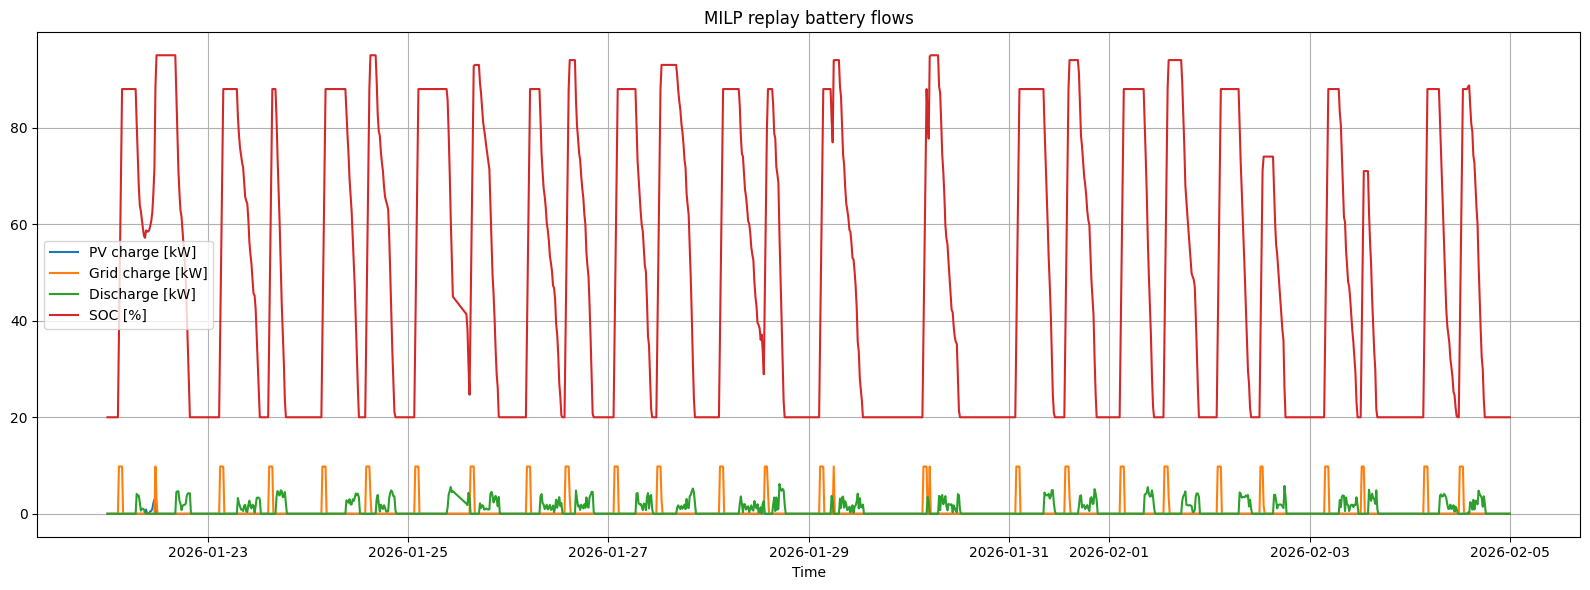

In [36]:
def plot_milp_battery_flows(milp_15: pd.DataFrame, start=None, end=None):
    df = milp_15.copy()
    if start is not None:
        df = df[df.index >= pd.to_datetime(start)]
    if end is not None:
        df = df[df.index <= pd.to_datetime(end)]

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(df.index, df["milp_exec_pv_charge_kw"], label="PV charge [kW]")
    ax.plot(df.index, df["milp_exec_grid_charge_kw"], label="Grid charge [kW]")
    ax.plot(df.index, df["milp_exec_discharge_kw"], label="Discharge [kW]")
    ax.plot(df.index, df["milp_soc_percent"], label="SOC [%]")

    ax.set_title("MILP replay battery flows")
    ax.set_xlabel("Time")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()
plot_milp_battery_flows(milp_15, start="2026-01-22", end="2026-02-05")

In [72]:
import sqlite3
import pandas as pd
import numpy as np
import json
import ast
import matplotlib.pyplot as plt

BATTERY_CAPACITY_KWH = 14.4
BATTERY_MIN_PERCENT = 20.0
BATTERY_MAX_PERCENT = 95.0
BATTERY_MAX_CHARGE_KW = 9.8
BATTERY_MAX_DISCHARGE_KW = 9.8

P_BAT_POSITIVE_IS_CHARGING = True
SPOT_IS_MWH = False


def _force_numeric(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )


def _parse_list_cell(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    if not s:
        return []
    try:
        return json.loads(s)
    except Exception:
        return ast.literal_eval(s)


def load_actual_data(db_path: str, table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            DateTime,
            SoC,
            P_BAT,
            P_PV,
            BUY_T,
            SELL_T,
            fromBAT_T,
            toBAT_T
        FROM {table_name}
        ORDER BY DateTime
        """,
        conn,
    )
    conn.close()

    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.set_index("DateTime").sort_index()

    for col in ["SoC", "P_BAT", "P_PV", "BUY_T", "SELL_T", "fromBAT_T", "toBAT_T"]:
        if col in df.columns:
            df[col] = _force_numeric(df[col])

    return df


def load_spot_data(db_path: str, table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            DateTime,
            Value
        FROM {table_name}
        ORDER BY DateTime
        """,
        conn,
    )
    conn.close()

    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.set_index("DateTime").sort_index()
    df = df.rename(columns={"Value": "spot_price"})
    df["spot_price"] = _force_numeric(df["spot_price"])

    if SPOT_IS_MWH:
        df["spot_price"] = df["spot_price"] / 1000.0

    return df


def load_milp_daily_plan(db_path: str, table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(
        f"""
        SELECT
            TimeStamp,
            ChargeTimes,
            DischargeTimes,
            ChargeToCapacities,
            PriceSum
        FROM {table_name}
        ORDER BY TimeStamp
        """,
        conn,
    )
    conn.close()

    df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])
    df["ChargeTimes"] = df["ChargeTimes"].apply(_parse_list_cell)
    df["DischargeTimes"] = df["DischargeTimes"].apply(_parse_list_cell)
    df["ChargeToCapacities"] = df["ChargeToCapacities"].apply(_parse_list_cell)
    if "PriceSum" in df.columns:
        df["PriceSum"] = _force_numeric(df["PriceSum"])
        df = df.rename(columns={"PriceSum": "PredictedCost"})

    return df

In [58]:
def compute_actual_cost_from_cumulative_prorated(
    df_actual: pd.DataFrame,
    df_spot: pd.DataFrame,
    max_interval_minutes: int = 60,
) -> pd.DataFrame:
    df = df_actual.copy().sort_index()
    spot = df_spot.copy().sort_index()

    out = spot.copy()
    out["buy_kwh"] = 0.0
    out["sell_kwh"] = 0.0

    prev_time = None
    prev_buy = None
    prev_sell = None

    for ts, row in df.iterrows():
        buy_t = row["BUY_T"]
        sell_t = row["SELL_T"]

        if prev_time is None:
            prev_time = ts
            prev_buy = buy_t
            prev_sell = sell_t
            continue

        if pd.isna(buy_t) or pd.isna(sell_t) or pd.isna(prev_buy) or pd.isna(prev_sell):
            prev_time = ts
            prev_buy = buy_t
            prev_sell = sell_t
            continue

        delta_buy = buy_t - prev_buy
        delta_sell = sell_t - prev_sell
        interval_min = (ts - prev_time).total_seconds() / 60.0

        if interval_min <= 0 or interval_min > max_interval_minutes:
            prev_time = ts
            prev_buy = buy_t
            prev_sell = sell_t
            continue

        if delta_buy < 0 or delta_sell < 0:
            prev_time = ts
            prev_buy = buy_t
            prev_sell = sell_t
            continue

        interval_start = prev_time
        interval_end = ts
        total_seconds = (interval_end - interval_start).total_seconds()

        bin_start = interval_start.floor("15min")
        bin_end = interval_end.floor("15min")
        bins = pd.date_range(bin_start, bin_end, freq="15min")

        for b in bins:
            b_start = b
            b_end = b + pd.Timedelta(minutes=15)

            overlap_start = max(interval_start, b_start)
            overlap_end = min(interval_end, b_end)
            overlap_seconds = (overlap_end - overlap_start).total_seconds()

            if overlap_seconds <= 0:
                continue

            weight = overlap_seconds / total_seconds

            if b in out.index:
                out.at[b, "buy_kwh"] += delta_buy * weight
                out.at[b, "sell_kwh"] += delta_sell * weight

        prev_time = ts
        prev_buy = buy_t
        prev_sell = sell_t

    out["actual_grid_net_kwh"] = out["buy_kwh"] - out["sell_kwh"]
    out["actual_cost"] = out["actual_grid_net_kwh"] * out["spot_price"]
    return out

In [59]:
def resample_battery_power_15(df_actual: pd.DataFrame, max_gap_minutes: int = 30) -> pd.DataFrame:
    df = df_actual.copy().sort_index()

    df["P_BAT_KW"] = df["P_BAT"] / 1000.0

    minute = df[["P_BAT_KW"]].resample("1min").mean()
    present = df[["P_BAT_KW"]].resample("1min").count()["P_BAT_KW"] > 0

    minute_interp = minute.interpolate(method="time", limit_area="inside")

    idx_series = pd.Series(minute.index, index=minute.index)
    real_times = idx_series.where(present)

    last_real = real_times.ffill()
    next_real = real_times.bfill()

    dist_left_min = (idx_series - last_real).dt.total_seconds() / 60.0
    dist_right_min = (next_real - idx_series).dt.total_seconds() / 60.0

    valid_bridge = (dist_left_min <= max_gap_minutes) & (dist_right_min <= max_gap_minutes)

    minute_clean = minute_interp.copy()
    minute_clean.loc[~valid_bridge, "P_BAT_KW"] = np.nan

    rs = minute_clean.resample("15min").mean()
    rs["raw_points"] = present.astype(int).resample("15min").sum()
    rs["low_coverage"] = rs["raw_points"] < 2

    return rs

In [60]:
def compute_no_battery_cost_from_counters_and_bat(
    actual_cost_15: pd.DataFrame,
    bat_15: pd.DataFrame,
    df_spot: pd.DataFrame,
) -> pd.DataFrame:
    out = (
        df_spot.copy()
        .join(actual_cost_15[["actual_grid_net_kwh"]], how="left")
        .join(bat_15[["P_BAT_KW", "low_coverage"]], how="left")
    )

    out = out.dropna(subset=["actual_grid_net_kwh", "spot_price", "P_BAT_KW"])
    out = out[out["low_coverage"] != True]

    dt = 0.25

    if P_BAT_POSITIVE_IS_CHARGING:
        actual_charge_kwh = out["P_BAT_KW"].clip(lower=0.0) * dt
        actual_discharge_kwh = (-out["P_BAT_KW"]).clip(lower=0.0) * dt
    else:
        actual_charge_kwh = (-out["P_BAT_KW"]).clip(lower=0.0) * dt
        actual_discharge_kwh = out["P_BAT_KW"].clip(lower=0.0) * dt

    out["actual_charge_kwh"] = actual_charge_kwh
    out["actual_discharge_kwh"] = actual_discharge_kwh

    out["nobatt_grid_net_kwh"] = (
        out["actual_grid_net_kwh"]
        - out["actual_charge_kwh"]
        + out["actual_discharge_kwh"]
    )

    out["nobatt_buy_kwh"] = out["nobatt_grid_net_kwh"].clip(lower=0.0)
    out["nobatt_sell_kwh"] = (-out["nobatt_grid_net_kwh"]).clip(lower=0.0)
    out["nobatt_cost"] = out["nobatt_grid_net_kwh"] * out["spot_price"]

    return out

In [61]:
def expand_milp_daily_plan_to_mode_changes(milp_daily: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, day in milp_daily.iterrows():
        charge_times = sorted(pd.to_datetime(day["ChargeTimes"]))
        discharge_times = sorted(pd.to_datetime(day["DischargeTimes"]))
        targets = [float(x) for x in day["ChargeToCapacities"]]

        charge_sessions = []
        if charge_times:
            current = [charge_times[0]]
            for t in charge_times[1:]:
                if (t - current[-1]) == pd.Timedelta(minutes=15):
                    current.append(t)
                else:
                    charge_sessions.append(current)
                    current = [t]
            charge_sessions.append(current)

        discharge_sessions = []
        if discharge_times:
            current = [discharge_times[0]]
            for t in discharge_times[1:]:
                if (t - current[-1]) == pd.Timedelta(minutes=15):
                    current.append(t)
                else:
                    discharge_sessions.append(current)
                    current = [t]
            discharge_sessions.append(current)

        for i, sess in enumerate(charge_sessions):
            if len(targets) == 0:
                target = None
            elif i < len(targets):
                target = targets[i]
            else:
                target = targets[-1]

            rows.append({
                "DateTime": sess[0],
                "mode": "charge",
                "target_soc_percent": target,
            })

        for sess in discharge_sessions:
            rows.append({
                "DateTime": sess[0],
                "mode": "discharge",
                "target_soc_percent": None,
            })

    out = pd.DataFrame(rows)
    out["DateTime"] = pd.to_datetime(out["DateTime"])
    return out.sort_values("DateTime").set_index("DateTime")

In [62]:
def replay_milp_without_phome(
    actual_cost_15: pd.DataFrame,
    bat_15: pd.DataFrame,
    df_spot: pd.DataFrame,
    milp_mode_changes: pd.DataFrame,
    actual_raw: pd.DataFrame,
    capacity_kwh: float = 14.4,
    min_percent: float = 20.0,
    max_percent: float = 95.0,
    max_charge_kw: float = 9.8,
    max_discharge_kw: float = 9.8,
) -> pd.DataFrame:
    raw_soc = actual_raw.copy()
    raw_soc["SoC"] = _force_numeric(raw_soc["SoC"])
    daily_initial_soc = raw_soc["SoC"].resample("1D").first()

    merged_base = (
        df_spot.copy()
        .join(actual_cost_15[["actual_grid_net_kwh"]], how="left")
        .join(bat_15[["P_BAT_KW", "low_coverage"]], how="left")
    )

    merged_base = merged_base.dropna(subset=["actual_grid_net_kwh", "spot_price", "P_BAT_KW"])
    merged_base = merged_base[merged_base["low_coverage"] != True]

    dt = 0.25
    all_rows = []

    for day_start, initial_soc_percent in daily_initial_soc.dropna().items():
        day_end = day_start + pd.Timedelta(days=1)

        base_day = merged_base.loc[(merged_base.index >= day_start) & (merged_base.index < day_end)]
        mode_day = milp_mode_changes.loc[(milp_mode_changes.index >= day_start) & (milp_mode_changes.index < day_end)]

        if base_day.empty:
            continue

        merged = base_day.join(mode_day[["mode", "target_soc_percent"]], how="left")

        soc_kwh = capacity_kwh * float(initial_soc_percent) / 100.0
        min_kwh = capacity_kwh * min_percent / 100.0
        max_kwh = capacity_kwh * max_percent / 100.0

        current_mode = None
        current_target_soc_kwh = None

        rows = []

        for ts, row in merged.iterrows():
            price = float(row["spot_price"])
            actual_grid_net_kwh = float(row["actual_grid_net_kwh"])
            actual_bat_kw = float(row["P_BAT_KW"])

            if P_BAT_POSITIVE_IS_CHARGING:
                actual_charge_kw = max(actual_bat_kw, 0.0)
                actual_discharge_kw = max(-actual_bat_kw, 0.0)
            else:
                actual_charge_kw = max(-actual_bat_kw, 0.0)
                actual_discharge_kw = max(actual_bat_kw, 0.0)

            # remove actual battery effect -> no-battery residual
            residual_nobatt_kwh = (
                actual_grid_net_kwh
                - actual_charge_kw * dt
                + actual_discharge_kw * dt
            )
            residual_nobatt_kw = residual_nobatt_kwh / dt

            surplus_kw = max(-residual_nobatt_kw, 0.0)
            deficit_kw = max(residual_nobatt_kw, 0.0)

            if pd.notna(row.get("mode")):
                current_mode = row["mode"]
                if current_mode == "charge" and pd.notna(row.get("target_soc_percent")):
                    current_target_soc_kwh = capacity_kwh * float(row["target_soc_percent"]) / 100.0
                    current_target_soc_kwh = min(max(current_target_soc_kwh, min_kwh), max_kwh)
                else:
                    current_target_soc_kwh = None

            free_room_kw = max((max_kwh - soc_kwh) / dt, 0.0)
            available_discharge_kw = max((soc_kwh - min_kwh) / dt, 0.0)

            # PV-first behavior from residual: negative residual = PV surplus
            executed_pv_charge = min(surplus_kw, max_charge_kw, free_room_kw)

            executed_grid_charge = 0.0
            executed_discharge = 0.0

            if current_mode == "charge":
                if current_target_soc_kwh is not None and soc_kwh < current_target_soc_kwh:
                    remaining_to_target_kw = max((current_target_soc_kwh - soc_kwh) / dt, 0.0)
                    remaining_charge_headroom_kw = max(max_charge_kw - executed_pv_charge, 0.0)
                    remaining_free_room_kw = max((max_kwh - soc_kwh) / dt - executed_pv_charge, 0.0)

                    executed_grid_charge = min(
                        remaining_to_target_kw,
                        remaining_charge_headroom_kw,
                        remaining_free_room_kw,
                    )
                else:
                    if current_target_soc_kwh is not None and soc_kwh >= current_target_soc_kwh:
                        current_mode = None

            elif current_mode == "discharge":
                executed_discharge = min(
                    max_discharge_kw,
                    deficit_kw,
                    available_discharge_kw,
                )
                if soc_kwh <= min_kwh + 1e-9:
                    current_mode = None

            milp_grid_net_kw = residual_nobatt_kw + executed_pv_charge + executed_grid_charge - executed_discharge
            milp_grid_net_kwh = milp_grid_net_kw * dt

            grid_buy_kwh = max(milp_grid_net_kwh, 0.0)
            grid_sell_kwh = max(-milp_grid_net_kwh, 0.0)

            soc_kwh = soc_kwh + (executed_pv_charge + executed_grid_charge - executed_discharge) * dt
            soc_kwh = min(max(soc_kwh, min_kwh), max_kwh)

            milp_cost = milp_grid_net_kwh * price

            rows.append({
                "DateTime": ts,
                "milp_mode": current_mode,
                "residual_nobatt_kw": residual_nobatt_kw,
                "milp_grid_buy_kwh": grid_buy_kwh,
                "milp_grid_sell_kwh": grid_sell_kwh,
                "milp_exec_pv_charge_kw": executed_pv_charge,
                "milp_exec_grid_charge_kw": executed_grid_charge,
                "milp_exec_discharge_kw": executed_discharge,
                "milp_soc_percent": soc_kwh * 100.0 / capacity_kwh,
                "milp_cost": milp_cost,
            })

        all_rows.extend(rows)

    return pd.DataFrame(all_rows).set_index("DateTime").sort_index()

In [75]:
def compute_no_battery_cost_from_counters(counter_15: pd.DataFrame) -> pd.DataFrame:
    out = counter_15.copy()

    out["nobatt_grid_net_kwh"] = (
        out["actual_grid_net_kwh"]
        - out["to_bat_kwh"]
        + out["from_bat_kwh"]
    )

    out["nobatt_buy_kwh"] = out["nobatt_grid_net_kwh"].clip(lower=0.0)
    out["nobatt_sell_kwh"] = (-out["nobatt_grid_net_kwh"]).clip(lower=0.0)
    out["nobatt_cost"] = out["nobatt_grid_net_kwh"] * out["spot_price"]

    return out

In [73]:
def compute_interval_energies_from_counters(
    df_actual: pd.DataFrame,
    df_spot: pd.DataFrame,
    max_interval_minutes: int = 60,
) -> pd.DataFrame:
    df = df_actual.copy().sort_index()
    spot = df_spot.copy().sort_index()

    for col in ["BUY_T", "SELL_T", "ToBAT_T", "FromBAT_T"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

    out = spot.copy()
    out["buy_kwh"] = 0.0
    out["sell_kwh"] = 0.0
    out["to_bat_kwh"] = 0.0
    out["from_bat_kwh"] = 0.0

    prev_time = None
    prev_vals = None

    for ts, row in df.iterrows():
        vals = row[["BUY_T", "SELL_T", "ToBAT_T", "FromBAT_T"]]

        if prev_time is None:
            prev_time = ts
            prev_vals = vals
            continue

        if vals.isna().any() or prev_vals.isna().any():
            prev_time = ts
            prev_vals = vals
            continue

        interval_min = (ts - prev_time).total_seconds() / 60.0
        if interval_min <= 0 or interval_min > max_interval_minutes:
            prev_time = ts
            prev_vals = vals
            continue

        deltas = vals - prev_vals
        if (deltas < 0).any():
            prev_time = ts
            prev_vals = vals
            continue

        interval_start = prev_time
        interval_end = ts
        total_seconds = (interval_end - interval_start).total_seconds()

        bin_start = interval_start.floor("15min")
        bin_end = interval_end.floor("15min")
        bins = pd.date_range(bin_start, bin_end, freq="15min")

        for b in bins:
            b_start = b
            b_end = b + pd.Timedelta(minutes=15)

            overlap_start = max(interval_start, b_start)
            overlap_end = min(interval_end, b_end)
            overlap_seconds = (overlap_end - overlap_start).total_seconds()

            if overlap_seconds <= 0:
                continue

            weight = overlap_seconds / total_seconds

            if b in out.index:
                out.at[b, "buy_kwh"] += deltas["BUY_T"] * weight
                out.at[b, "sell_kwh"] += deltas["SELL_T"] * weight
                out.at[b, "to_bat_kwh"] += deltas["ToBAT_T"] * weight
                out.at[b, "from_bat_kwh"] += deltas["FromBAT_T"] * weight

        prev_time = ts
        prev_vals = vals

    out["actual_grid_net_kwh"] = out["buy_kwh"] - out["sell_kwh"]
    out["actual_cost"] = out["actual_grid_net_kwh"] * out["spot_price"]
    return out

In [108]:
def compute_milp_cost_from_counters_and_plan(
    counter_15: pd.DataFrame,
    milp_15: pd.DataFrame,
) -> pd.DataFrame:
    out = counter_15.copy().join(
        milp_15[[
            "milp_exec_pv_charge_kw",
            "milp_exec_grid_charge_kw",
            "milp_exec_discharge_kw",
            "milp_soc_percent",
        ]],
        how="left"
    )

    out["milp_exec_pv_charge_kw"] = out["milp_exec_pv_charge_kw"].fillna(0.0)
    out["milp_exec_grid_charge_kw"] = out["milp_exec_grid_charge_kw"].fillna(0.0)
    out["milp_exec_discharge_kw"] = out["milp_exec_discharge_kw"].fillna(0.0)

    dt = 0.25
    out["milp_charge_kwh"] = (out["milp_exec_pv_charge_kw"] + out["milp_exec_grid_charge_kw"]) * dt
    out["milp_discharge_kwh"] = out["milp_exec_discharge_kw"] * dt

    # remove actual battery behavior, add MILP battery behavior
    out["milp_grid_net_kwh"] = (
        out["actual_grid_net_kwh"]
        - out["to_bat_kwh"]
        + out["from_bat_kwh"]
        + out["milp_charge_kwh"]
        - out["milp_discharge_kwh"]
    )

    out["milp_buy_kwh"] = out["milp_grid_net_kwh"].clip(lower=0.0)
    out["milp_sell_kwh"] = (-out["milp_grid_net_kwh"]).clip(lower=0.0)
    out["milp_cost"] = out["milp_grid_net_kwh"] * out["spot_price"]

    return out

In [135]:
def replay_milp_state_machine_without_phome(
    counter_15: pd.DataFrame,
    milp_mode_changes: pd.DataFrame,
    actual_raw: pd.DataFrame,
    capacity_kwh: float = 14.4,
    min_percent: float = 20.0,
    max_percent: float = 95.0,
    max_charge_kw: float = 7.5,
    max_discharge_kw: float = 7.5,
) -> pd.DataFrame:
    raw_soc = actual_raw.copy()
    raw_soc["SoC"] = (
        raw_soc["SoC"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )
    daily_initial_soc = raw_soc["SoC"].resample("1D").first()

    all_rows = []
    dt = 0.25

    for day_start, initial_soc_percent in daily_initial_soc.dropna().items():
        day_end = day_start + pd.Timedelta(days=1)

        base_day = counter_15.loc[(counter_15.index >= day_start) & (counter_15.index < day_end)].copy()
        mode_day = milp_mode_changes.loc[(milp_mode_changes.index >= day_start) & (milp_mode_changes.index < day_end)]

        if base_day.empty:
            continue

        merged = base_day.join(mode_day[["mode", "target_soc_percent"]], how="left")

        soc_kwh = capacity_kwh * float(initial_soc_percent) / 100.0
        min_kwh = capacity_kwh * min_percent / 100.0
        max_kwh = capacity_kwh * max_percent / 100.0

        current_mode = None
        current_target_soc_kwh = None

        rows = []

        for ts, row in merged.iterrows():
            price = float(row["spot_price"])

            # remove actual battery effect -> no-battery base residual
            nobatt_grid_net_kwh = (
                float(row["actual_grid_net_kwh"])
                - float(row["to_bat_kwh"])
                + float(row["from_bat_kwh"])
            )

            nobatt_grid_net_kw = nobatt_grid_net_kwh / dt

            # Interpret residual:
            # positive -> deficit after PV
            # negative -> PV surplus after house load
            surplus_kw = max(-nobatt_grid_net_kw, 0.0)
            deficit_kw = max(nobatt_grid_net_kw, 0.0)

            if pd.notna(row.get("mode")):
                current_mode = row["mode"]
                if current_mode == "charge" and pd.notna(row.get("target_soc_percent")):
                    current_target_soc_kwh = capacity_kwh * float(row["target_soc_percent"]) / 100.0
                    current_target_soc_kwh = min(max(current_target_soc_kwh, min_kwh), max_kwh)
                else:
                    current_target_soc_kwh = None

            free_room_kw = max((max_kwh - soc_kwh) / dt, 0.0)
            available_discharge_kw = max((soc_kwh - min_kwh) / dt, 0.0)

            # PV surplus always charges battery first
            executed_pv_charge = min(surplus_kw, max_charge_kw, free_room_kw)

            executed_grid_charge = 0.0
            executed_discharge = 0.0

            if current_mode == "charge":
                if current_target_soc_kwh is not None and soc_kwh < current_target_soc_kwh:
                    remaining_to_target_kw = max((current_target_soc_kwh - soc_kwh) / dt, 0.0)
                    remaining_charge_headroom_kw = max(max_charge_kw - executed_pv_charge, 0.0)
                    remaining_free_room_kw = max((max_kwh - soc_kwh) / dt - executed_pv_charge, 0.0)

                    executed_grid_charge = min(
                        remaining_to_target_kw,
                        remaining_charge_headroom_kw,
                        remaining_free_room_kw,
                    )
                else:
                    if current_target_soc_kwh is not None and soc_kwh >= current_target_soc_kwh:
                        current_mode = None

            elif current_mode == "discharge":
                executed_discharge = min(
                    max_discharge_kw,
                    deficit_kw,
                    available_discharge_kw,
                )

                if soc_kwh <= min_kwh + 1e-9:
                    current_mode = None

            # remaining PV surplus after battery charge goes to grid
            grid_sell_kw = max(surplus_kw - executed_pv_charge, 0.0)

            # remaining deficit after discharge plus optional grid charging
            grid_buy_kw = max(deficit_kw - executed_discharge + executed_grid_charge, 0.0)

            grid_buy_kwh = grid_buy_kw * dt
            grid_sell_kwh = grid_sell_kw * dt

            soc_kwh = soc_kwh + (executed_pv_charge + executed_grid_charge - executed_discharge) * dt
            soc_kwh = min(max(soc_kwh, min_kwh), max_kwh)

            milp_cost = (grid_buy_kwh - grid_sell_kwh) * price

            rows.append({
                "DateTime": ts,
                "milp_mode": current_mode,
                "nobatt_grid_net_kwh": nobatt_grid_net_kwh,
                "milp_grid_buy_kwh": grid_buy_kwh,
                "milp_grid_sell_kwh": grid_sell_kwh,
                "milp_exec_pv_charge_kw": executed_pv_charge,
                "milp_exec_grid_charge_kw": executed_grid_charge,
                "milp_exec_discharge_kw": executed_discharge,
                "milp_soc_percent": soc_kwh * 100.0 / capacity_kwh,
                "milp_cost": milp_cost,
            })

        all_rows.extend(rows)

    return pd.DataFrame(all_rows).set_index("DateTime").sort_index()

In [136]:
actual_raw = load_actual_data("FVEDB.db", "MqttData")
spot = load_spot_data("FVEDB.db", "SpotData")

counter_15 = compute_interval_energies_from_counters(actual_raw, spot)
nobatt_15 = compute_no_battery_cost_from_counters(counter_15)

milp_daily = load_milp_daily_plan("FVEDB.db", "PredictedControlData")
milp_mode_changes = expand_milp_daily_plan_to_mode_changes(milp_daily)

# this is your existing replay, or the state-machine replay
milp_15 = replay_milp_state_machine_without_phome(
    counter_15=counter_15,
    milp_mode_changes=milp_mode_changes,
    actual_raw=actual_raw,
)

milp_counter_15 = compute_milp_cost_from_counters_and_plan(counter_15, milp_15)

In [109]:
milp_counter_15

,spot_price,buy_kwh,sell_kwh,to_bat_kwh,from_bat_kwh,actual_grid_net_kwh,actual_cost,milp_exec_pv_charge_kw,milp_exec_grid_charge_kw,milp_exec_discharge_kw,milp_soc_percent,milp_charge_kwh,milp_discharge_kwh,milp_grid_net_kwh,milp_buy_kwh,milp_sell_kwh,milp_cost
DateTime,,,,,,,,,,,,,,,,,
2025-11-01 00:00:00,2.252437,0.420,0.0,0.0,0.0,0.420,0.946024,0.0,0.0,0.0,20.0,0.0,0.0,0.420,0.420,0.0,0.946024
2025-11-01 00:15:00,1.790710,0.215,0.0,0.0,0.0,0.215,0.385003,0.0,0.0,0.0,20.0,0.0,0.0,0.215,0.215,0.0,0.385003
2025-11-01 00:30:00,1.533574,0.212,0.0,0.0,0.0,0.212,0.325118,0.0,0.0,0.0,20.0,0.0,0.0,0.212,0.212,0.0,0.325118
2025-11-01 00:45:00,1.459620,0.540,0.0,0.0,0.0,0.540,0.788195,0.0,0.0,0.0,20.0,0.0,0.0,0.540,0.540,0.0,0.788195
2025-11-01 01:00:00,1.930104,0.212,0.0,0.0,0.0,0.212,0.409182,0.0,0.0,0.0,20.0,0.0,0.0,0.212,0.212,0.0,0.409182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-07 22:45:00,3.003576,0.000,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,NaN,0.0,0.0,0.000,0.000,-0.0,0.000000
2026-04-07 23:00:00,3.185841,0.000,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,NaN,0.0,0.0,0.000,0.000,-0.0,0.000000
2026-04-07 23:15:00,2.931945,0.000,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,NaN,0.0,0.0,0.000,0.000,-0.0,0.000000


In [137]:
daily = pd.DataFrame({
    "actual_cost": actual_cost_15["actual_cost"].resample("1D").sum(),
    "no_battery_cost": nobatt_15["nobatt_cost"].resample("1D").sum(),
    "milp_cost": milp_counter_15["milp_cost"].resample("1D").sum(),
}).join(
    milp_daily.set_index(milp_daily["TimeStamp"].dt.floor("1D"))[["PredictedCost"]].rename(columns={"PredictedCost": "predicted_cost"}),
    how="left"
)

daily["battery_actual_saving"] = daily["no_battery_cost"] - daily["actual_cost"]
daily["milp_vs_actual_saving"] = daily["actual_cost"] - daily["milp_cost"]
daily["milp_vs_nobatt_saving"] = daily["no_battery_cost"] - daily["milp_cost"]
daily["predicted_vs_replay_diff"] = daily["predicted_cost"] - daily["milp_cost"]

display(daily.round(2))

,actual_cost,no_battery_cost,milp_cost,predicted_cost,battery_actual_saving,milp_vs_actual_saving,milp_vs_nobatt_saving,predicted_vs_replay_diff
DateTime,,,,,,,,
2025-11-01,35.20,42.29,47.21,NaN,7.09,-12.01,-4.91,NaN
2025-11-02,100.64,100.64,100.64,NaN,0.00,0.00,0.00,NaN
2025-11-03,88.55,88.31,88.31,NaN,-0.23,0.23,0.00,NaN
2025-11-04,89.70,88.48,92.71,NaN,-1.22,-3.01,-4.23,NaN
2025-11-05,46.27,53.50,74.23,NaN,7.23,-27.96,-20.73,NaN
...,...,...,...,...,...,...,...,...
2026-04-03,64.66,85.31,89.09,NaN,20.65,-24.43,-3.77,NaN
2026-04-04,55.24,67.97,68.23,NaN,12.73,-12.99,-0.26,NaN
2026-04-05,3.93,8.71,8.71,NaN,4.78,-4.78,0.00,NaN


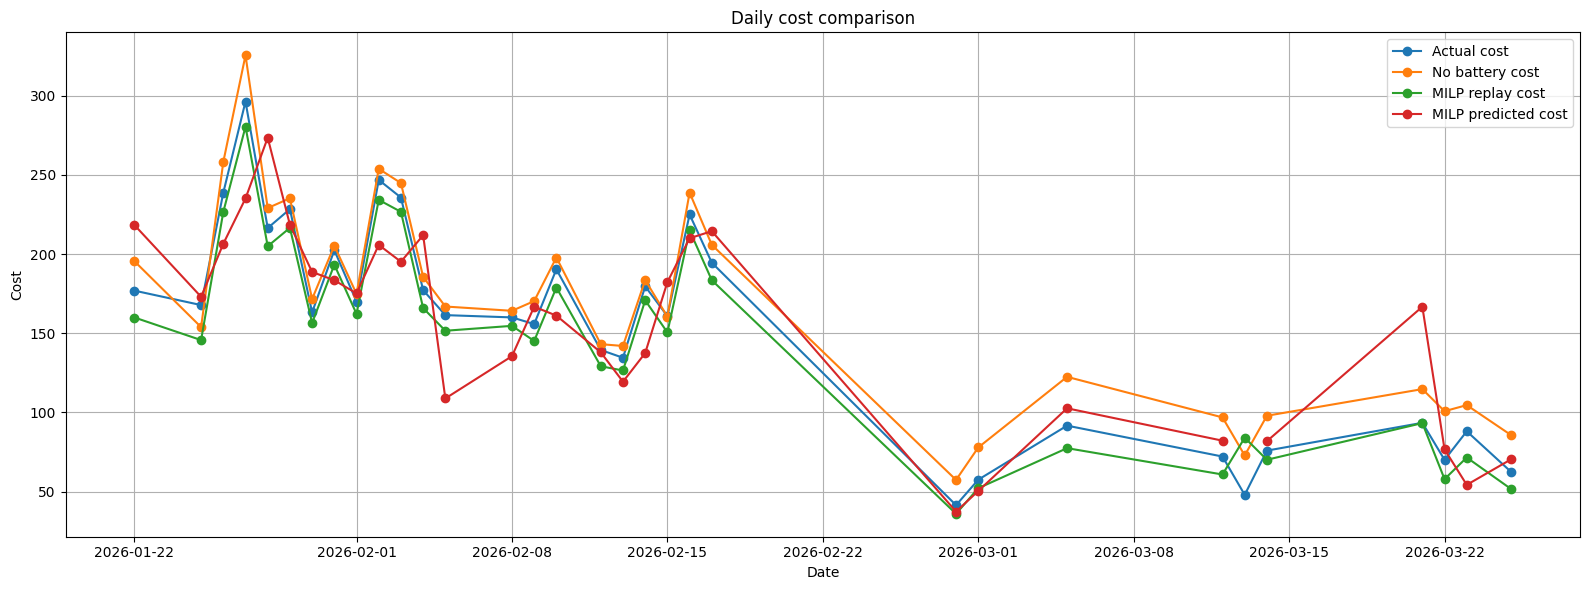

Number of calculated days:
32


In [142]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_daily_costs(
    daily: pd.DataFrame,
    start=None,
    end=None,
    all_days_quality: pd.DataFrame | None = None,
):
    df = daily.copy()

    if start is not None:
        start = pd.to_datetime(start)
        df = df[df.index >= start]
    if end is not None:
        end = pd.to_datetime(end)
        df = df[df.index <= end]

    fig, ax = plt.subplots(figsize=(16, 6))

    # lines + actual calculated points
    if "actual_cost" in df.columns:
        ax.plot(df.index, df["actual_cost"], label="Actual cost", marker="o")
    if "no_battery_cost" in df.columns:
        ax.plot(df.index, df["no_battery_cost"], label="No battery cost", marker="o")
    if "milp_cost" in df.columns:
        ax.plot(df.index, df["milp_cost"], label="MILP replay cost", marker="o")
    if "predicted_cost" in df.columns:
        ax.plot(df.index, df["predicted_cost"], label="MILP predicted cost", marker="o")

    # optionally shade excluded/bad days
    if all_days_quality is not None:
        q = all_days_quality.copy()

        if start is not None:
            q = q[q.index >= start]
        if end is not None:
            q = q[q.index <= end]

        if "bad_day" in q.columns:
            bad_days = q[q["bad_day"]].index
            for d in bad_days:
                ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.08)

    ax.set_title("Daily cost comparison")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cost")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print("Number of calculated days:")
    print(len(df.index))
plot_daily_costs(daily_range_filtered, start="2026-01-22", end="2026-03-30")

In [139]:
daily_range = daily.loc["2026-01-22":"2026-03-30"]

print("Average savings in selected range:")
print(f"MILP vs actual:      {daily_range['milp_vs_actual_saving'].mean():.2f}")
print(f"MILP vs no battery:  {daily_range['milp_vs_nobatt_saving'].mean():.2f}")
print(f"Actual vs no battery:{daily_range['battery_actual_saving'].mean():.2f}")

Average savings in selected range:
MILP vs actual:      6.13
MILP vs no battery:  17.95
Actual vs no battery:11.82


In [138]:
daily_range = daily.loc["2026-01-22":"2026-03-30"]
avg_summary = pd.DataFrame({
    "metric": [
        "MILP vs actual",
        "MILP vs no battery",
        "Actual vs no battery",
    ],
    "average_saving": [
        daily_range["milp_vs_actual_saving"].mean(),
        daily_range["milp_vs_nobatt_saving"].mean(),
        daily_range["battery_actual_saving"].mean(),
    ]
})

display(avg_summary.round(2))

,metric,average_saving
0,MILP vs actual,6.13
1,MILP vs no battery,17.95
2,Actual vs no battery,11.82


In [83]:
def build_daily_data_quality(resampled_15: pd.DataFrame) -> pd.DataFrame:
    df = resampled_15.copy()

    # whether the key signals exist in each 15-min bin
    df["has_home"] = df["P_HOME"].notna()
    df["has_pv"] = df["P_PV"].notna()

    # one row per day
    daily_quality = pd.DataFrame({
        "total_bins": df["has_home"].resample("1D").size(),
        "home_present_bins": df["has_home"].resample("1D").sum(),
        "pv_present_bins": df["has_pv"].resample("1D").sum(),
    })

    daily_quality["home_missing_bins"] = daily_quality["total_bins"] - daily_quality["home_present_bins"]
    daily_quality["pv_missing_bins"] = daily_quality["total_bins"] - daily_quality["pv_present_bins"]

    daily_quality["home_missing_share"] = daily_quality["home_missing_bins"] / daily_quality["total_bins"]
    daily_quality["pv_missing_share"] = daily_quality["pv_missing_bins"] / daily_quality["total_bins"]

    if "low_coverage" in df.columns:
        daily_quality["low_coverage_bins"] = df["low_coverage"].fillna(False).resample("1D").sum()
        daily_quality["low_coverage_share"] = daily_quality["low_coverage_bins"] / daily_quality["total_bins"]
    else:
        daily_quality["low_coverage_bins"] = 0
        daily_quality["low_coverage_share"] = 0.0

    if "high_interpolation_share" in df.columns:
        daily_quality["high_interp_bins"] = df["high_interpolation_share"].fillna(False).resample("1D").sum()
        daily_quality["high_interp_share"] = daily_quality["high_interp_bins"] / daily_quality["total_bins"]
    else:
        daily_quality["high_interp_bins"] = 0
        daily_quality["high_interp_share"] = 0.0

    return daily_quality


In [92]:
def flag_bad_days(
    daily_quality: pd.DataFrame,
    max_missing_share: float = 0.10,
    max_low_coverage_share: float = 0.10,
    max_high_interp_share: float = 0.10,
) -> pd.DataFrame:
    dq = daily_quality.copy()

    dq["bad_day"] = (
        (dq["home_missing_share"] > max_missing_share) |
        (dq["pv_missing_share"] > max_missing_share) |
        (dq["low_coverage_share"] > max_low_coverage_share) |
        (dq["high_interp_share"] > max_high_interp_share)
    )

    dq["good_day"] = ~dq["bad_day"]
    return dq

In [140]:
good_day_index = daily_quality[daily_quality["good_day"]].index

daily_filtered = daily.loc[daily.index.intersection(good_day_index)].copy()
daily_range_filtered = daily_filtered.loc["2026-01-22":"2026-03-30"]

In [141]:
print("Average savings on good days only:")
print(f"MILP vs actual:      {daily_range_filtered['milp_vs_actual_saving'].mean():.2f}")
print(f"MILP vs no battery:  {daily_range_filtered['milp_vs_nobatt_saving'].mean():.2f}")
print(f"Actual vs no battery:{daily_range_filtered['battery_actual_saving'].mean():.2f}")

Average savings on good days only:
MILP vs actual:      9.02
MILP vs no battery:  22.00
Actual vs no battery:12.98


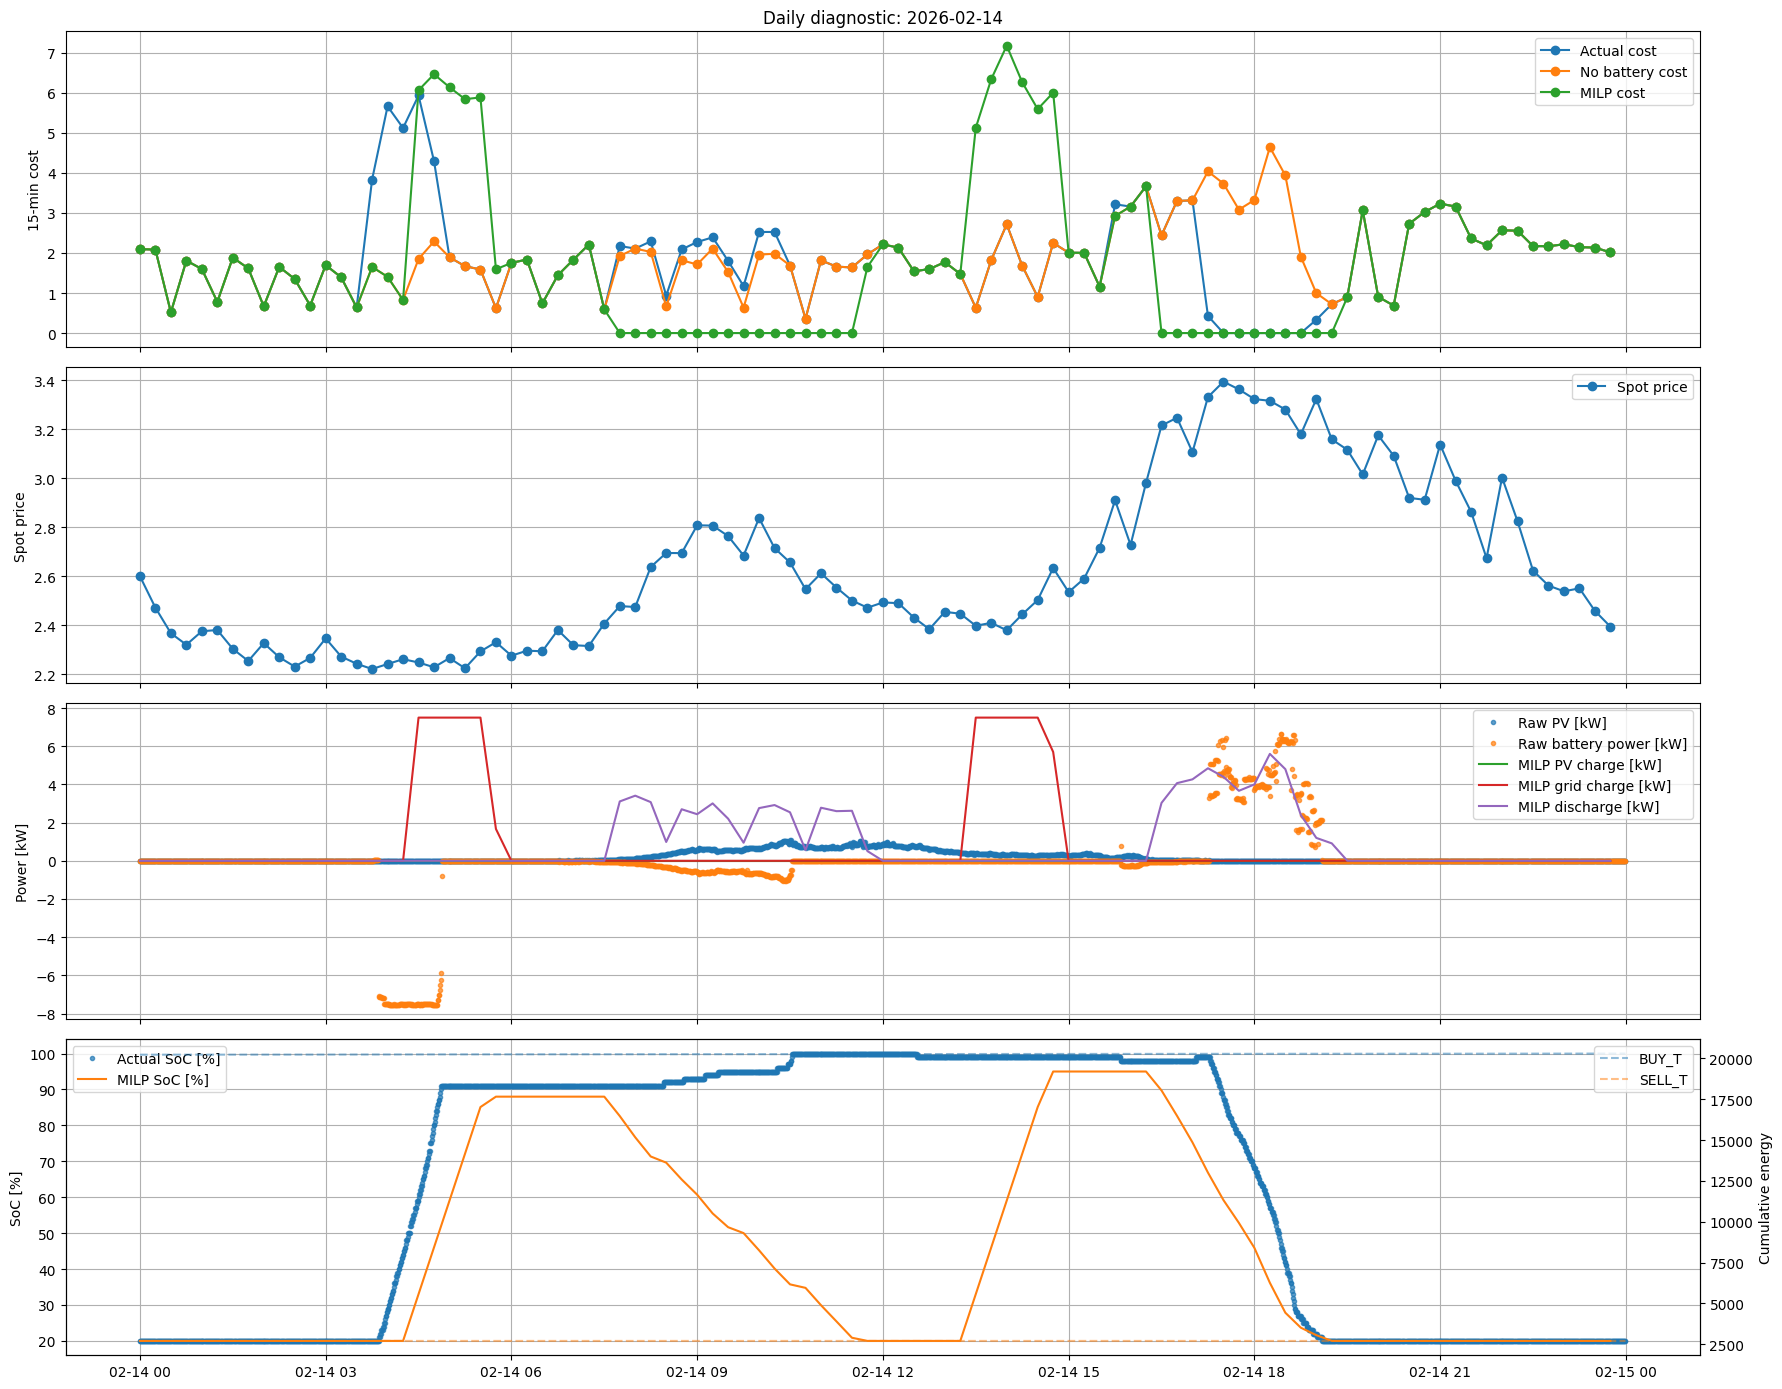

,actual_cost,no_battery_cost,milp_cost,predicted_cost,battery_actual_saving,milp_vs_actual_saving,milp_vs_nobatt_saving,predicted_vs_replay_diff
DateTime,,,,,,,,
2026-02-14,179.66,183.62,170.83,137.54,3.97,8.83,12.8,-33.29


In [145]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_one_day_diagnostic(
    day,
    actual_cost_15: pd.DataFrame,
    nobatt_15: pd.DataFrame,
    milp_15: pd.DataFrame | None,
    spot: pd.DataFrame,
    actual_raw: pd.DataFrame,
):
    day = pd.to_datetime(day).normalize()
    day_end = day + pd.Timedelta(days=1)

    # 15-minute data
    actual_day = actual_cost_15.loc[(actual_cost_15.index >= day) & (actual_cost_15.index < day_end)].copy()
    nobatt_day = nobatt_15.loc[(nobatt_15.index >= day) & (nobatt_15.index < day_end)].copy()
    spot_day = spot.loc[(spot.index >= day) & (spot.index < day_end)].copy()

    milp_day = None
    if milp_15 is not None:
        milp_day = milp_15.loc[(milp_15.index >= day) & (milp_15.index < day_end)].copy()

    # raw data
    raw_day = actual_raw.loc[(actual_raw.index >= day) & (actual_raw.index < day_end)].copy()

    # numeric conversion for raw columns
    for col in ["P_PV", "P_BAT", "SoC", "BUY_T", "SELL_T"]:
        if col in raw_day.columns:
            raw_day[col] = (
                raw_day[col]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .pipe(pd.to_numeric, errors="coerce")
            )

    # convert powers to kW for readability
    if "P_PV" in raw_day.columns:
        raw_day["P_PV_KW"] = raw_day["P_PV"] / 1000.0
    if "P_BAT" in raw_day.columns:
        raw_day["P_BAT_KW"] = raw_day["P_BAT"] / 1000.0

    fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)

    # 1) 15-minute costs
    axes[0].plot(actual_day.index, actual_day["actual_cost"], label="Actual cost", marker="o")
    axes[0].plot(nobatt_day.index, nobatt_day["nobatt_cost"], label="No battery cost", marker="o")

    if milp_day is not None and "milp_cost" in milp_day.columns:
        axes[0].plot(milp_day.index, milp_day["milp_cost"], label="MILP cost", marker="o")

    axes[0].set_title(f"Daily diagnostic: {day.date()}")
    axes[0].set_ylabel("15-min cost")
    axes[0].grid(True)
    axes[0].legend()

    # 2) Spot price
    if "spot_price" in spot_day.columns:
        axes[1].plot(spot_day.index, spot_day["spot_price"], label="Spot price", marker="o")
    axes[1].set_ylabel("Spot price")
    axes[1].grid(True)
    axes[1].legend()

    # 3) Raw measured PV / battery power
    if "P_PV_KW" in raw_day.columns:
        axes[2].plot(raw_day.index, raw_day["P_PV_KW"], ".", label="Raw PV [kW]", alpha=0.7)
    if "P_BAT_KW" in raw_day.columns:
        axes[2].plot(raw_day.index, raw_day["P_BAT_KW"], ".", label="Raw battery power [kW]", alpha=0.7)

    if milp_day is not None:
        if "milp_exec_pv_charge_kw" in milp_day.columns:
            axes[2].plot(milp_day.index, milp_day["milp_exec_pv_charge_kw"], label="MILP PV charge [kW]")
        if "milp_exec_grid_charge_kw" in milp_day.columns:
            axes[2].plot(milp_day.index, milp_day["milp_exec_grid_charge_kw"], label="MILP grid charge [kW]")
        if "milp_exec_discharge_kw" in milp_day.columns:
            axes[2].plot(milp_day.index, milp_day["milp_exec_discharge_kw"], label="MILP discharge [kW]")

    axes[2].set_ylabel("Power [kW]")
    axes[2].grid(True)
    axes[2].legend()

    # 4) SOC and cumulative counters
    if "SoC" in raw_day.columns:
        axes[3].plot(raw_day.index, raw_day["SoC"], ".", label="Actual SoC [%]", alpha=0.7)

    if milp_day is not None and "milp_soc_percent" in milp_day.columns:
        axes[3].plot(milp_day.index, milp_day["milp_soc_percent"], label="MILP SoC [%]")

    ax2 = axes[3].twinx()
    if "BUY_T" in raw_day.columns:
        ax2.plot(raw_day.index, raw_day["BUY_T"], "--", label="BUY_T", alpha=0.5)
    if "SELL_T" in raw_day.columns:
        ax2.plot(raw_day.index, raw_day["SELL_T"], "--", label="SELL_T", alpha=0.5)

    axes[3].set_ylabel("SoC [%]")
    ax2.set_ylabel("Cumulative energy")
    axes[3].grid(True)
    axes[3].legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

def show_one_day_table(day, daily: pd.DataFrame):
    day = pd.to_datetime(day).normalize()
    display(daily.loc[day:day].round(2))

day = "2026-02-14"
plot_one_day_diagnostic(
    day=day,
    actual_cost_15=actual_cost_15,
    nobatt_15=nobatt_15,
    milp_15=milp_counter_15,
    spot=spot,
    actual_raw=actual_raw,
)

show_one_day_table(day, daily_range_filtered)

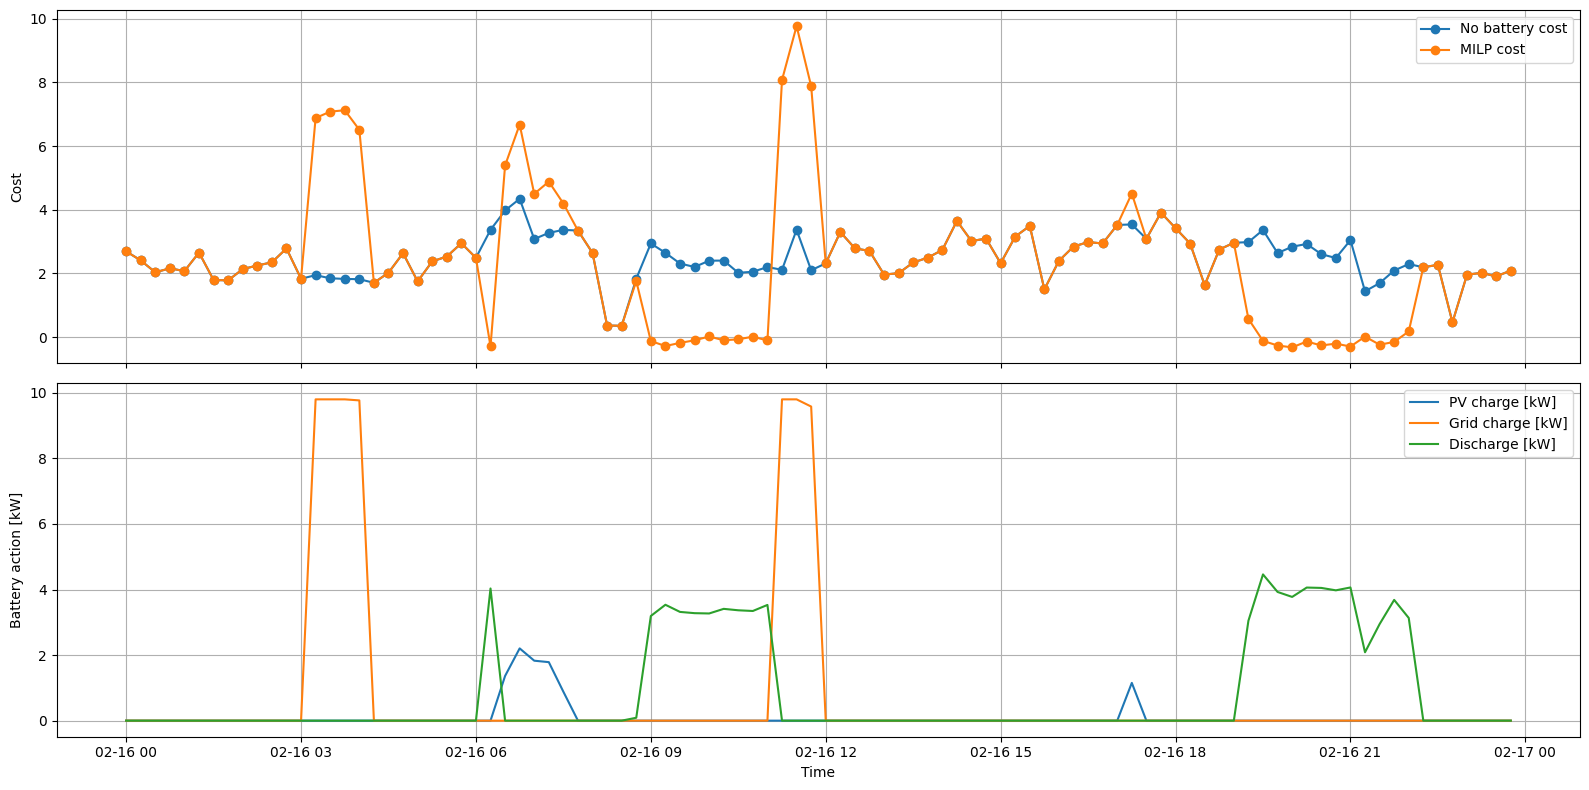

In [110]:
def plot_compare_with_milp_actions(day, nobatt_15, milp_15):
    day = pd.to_datetime(day).normalize()
    day_end = day + pd.Timedelta(days=1)

    n = nobatt_15.loc[(nobatt_15.index >= day) & (nobatt_15.index < day_end)]
    m = milp_15.loc[(milp_15.index >= day) & (milp_15.index < day_end)]

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    axes[0].plot(n.index, n["nobatt_cost"], label="No battery cost", marker="o")
    axes[0].plot(m.index, m["milp_cost"], label="MILP cost", marker="o")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_ylabel("Cost")

    axes[1].plot(m.index, m["milp_exec_pv_charge_kw"], label="PV charge [kW]")
    axes[1].plot(m.index, m["milp_exec_grid_charge_kw"], label="Grid charge [kW]")
    axes[1].plot(m.index, m["milp_exec_discharge_kw"], label="Discharge [kW]")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_ylabel("Battery action [kW]")
    axes[1].set_xlabel("Time")

    plt.tight_layout()
    plt.show()
# plot_compare_with_milp_actions("2026-02-16", nobatt_15, milp_15)
plot_compare_with_milp_actions("2026-02-16", nobatt_15, milp_counter_15)
